# DATA UNDERSTANDING

In [1]:
# All useful library to import

# library for the visualization
import seaborn as sns
import matplotlib.pyplot as plt

# library for data handling
import pandas as pd
import numpy as np

# utility
from utils import *

## Cyclists Dataset

In [2]:
dataset_cyclists = pd.read_csv("../dataset/dataset/cyclists.csv")

### General Overview of the Cyclist Dataset

In [3]:
dataset_cyclists.head()

,_url,name,birth_year,weight,height,nationality
0,bruno-surra,Bruno Surra,1964.0,NaN,NaN,Italy
1,gerard-rue,Gérard Rué,1965.0,74.0,182.0,France
2,jan-maas,Jan Maas,1996.0,69.0,189.0,Netherlands
3,nathan-van-hooydonck,Nathan Van Hooydonck,1995.0,78.0,192.0,Belgium
4,jose-felix-parra,José Félix Parra,1997.0,55.0,171.0,Spain


In [4]:
dataset_cyclists.shape

(6134, 6)

In [5]:
dataset_cyclists.describe()

,birth_year,weight,height
count,6121.000000,3078.000000,3143.000000
mean,1974.071884,68.658739,179.815145
std,15.535834,6.348183,6.443447
min,1933.000000,48.000000,154.000000
25%,1962.000000,64.000000,175.000000
50%,1974.000000,69.000000,180.000000
75%,1987.000000,73.000000,184.000000
max,2004.000000,94.000000,204.000000


In [6]:
dataset_cyclists.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6134 entries, 0 to 6133
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   _url         6134 non-null   object 
 1   name         6134 non-null   object 
 2   birth_year   6121 non-null   float64
 3   weight       3078 non-null   float64
 4   height       3143 non-null   float64
 5   nationality  6133 non-null   object 
dtypes: float64(3), object(3)
memory usage: 287.7+ KB


In [7]:
dataset_cyclists.columns

Index(['_url', 'name', 'birth_year', 'weight', 'height', 'nationality'], dtype='object')

This dataset is a **Data Matrix** and consists of:
- 6134 rows corresponding to cyclists  
- 6 columns corresponding to the following features for each cyclist: 
*'_url', 'name', 'birth_year', 'weight', 'height' and 'nationality'*

In [8]:
# data types in cyclists dataset
dataset_cyclists.dtypes

_url            object
name            object
birth_year     float64
weight         float64
height         float64
nationality     object
dtype: object

- #### _url is a **Nominal** attribute:
 It represents the cyclist's url where information pertaining to the cyclist can be found.
- #### name is a **Nominal** attribute:
 It represents the name of the cyclist.
- #### birth_year is a **Numerical** attribute:
 It represents the date of birth of the cyclist.
- #### weight is a **Numerical** attribute:
 It represents the weight of the cyclist.
- #### height is a **Numerical** attribute:
 It represents the height of the cyclist.
- #### nationality is a **Nominal** attribute:
 It represents the nationality of the cyclist.

In [9]:
# to take a look at each column
dataset_cyclists["_url"],dataset_cyclists["name"],dataset_cyclists["birth_year"],\
    dataset_cyclists["weight"],dataset_cyclists["height"],dataset_cyclists["nationality"]

(0                   bruno-surra
 1                    gerard-rue
 2                      jan-maas
 3          nathan-van-hooydonck
 4              jose-felix-parra
                  ...           
 6129    juan-jose-martinez-diaz
 6130             inigo-elosegui
 6131             paolo-alberati
 6132          jackson-rodriguez
 6133               ward-vanhoof
 Name: _url, Length: 6134, dtype: object,
 0               Bruno  Surra
 1                Gérard  Rué
 2                  Jan  Maas
 3       Nathan Van Hooydonck
 4          José Félix  Parra
                 ...         
 6129     Juan José  Martínez
 6130         Iñigo  Elosegui
 6131         Paolo  Alberati
 6132      Jackson  Rodríguez
 6133           Ward  Vanhoof
 Name: name, Length: 6134, dtype: object,
 0       1964.0
 1       1965.0
 2       1996.0
 3       1995.0
 4       1997.0
          ...  
 6129    1966.0
 6130    1998.0
 6131    1973.0
 6132    1985.0
 6133    1999.0
 Name: birth_year, Length: 6134, dtype: float64

In [10]:
# to see how many unique values each feature has (this command also counts the missing value (Nan) as a unique value)
features = ["_url", "name", "birth_year", "weight", "height", "nationality"]

for feature in features:
    unique_count = len(dataset_cyclists[feature].unique())
    print(f"Feature '{feature}' has {unique_count} unique values")

Feature '_url' has 6134 unique values
Feature 'name' has 6127 unique values
Feature 'birth_year' has 72 unique values
Feature 'weight' has 60 unique values
Feature 'height' has 49 unique values
Feature 'nationality' has 73 unique values


#### We can see that the urls as they should be are all different. As far as the names are concerned we have 7 of them repeating:

In [11]:
dataset_cyclists[dataset_cyclists["name"].duplicated(keep=False)].sort_values(by="name")

,_url,name,birth_year,weight,height,nationality
2953,alberto-fernandez-sainz,Alberto Fernández,1981.0,NaN,NaN,Spain
5720,alberto-fernandez-blanco,Alberto Fernández,1955.0,NaN,NaN,Spain
2235,alessandro-pozzi2,Alessandro Pozzi,1969.0,NaN,NaN,Italy
5722,alessandro-pozzi,Alessandro Pozzi,1954.0,NaN,NaN,Italy
347,andrea-peron-1,Andrea Peron,1971.0,70.0,183.0,Italy
2682,andrea-peron,Andrea Peron,1988.0,70.0,178.0,Italy
2862,antonio-cabello-baena,Antonio Cabello,1990.0,67.0,179.0,Spain
3238,antonio-cabello,Antonio Cabello,1956.0,NaN,NaN,Spain
2939,jesus-lopez23,Jesús López,1955.0,NaN,NaN,Spain
5040,jesus-lopez-carril,Jesús López,1949.0,NaN,NaN,Spain


#### After a check on the internet also thanks to the urls provided by the dataset, we could see that these duplicate names are homonyms and therefore the rows in the dataset actually correspond to different cyclists

In [12]:
# to see how many and what are the unique feature values (this command instead does not count the missing value (NaN))
dataset_cyclists["_url"].value_counts(), dataset_cyclists["name"].value_counts(),\
    dataset_cyclists["birth_year"].value_counts(), dataset_cyclists["weight"].value_counts(),\
        dataset_cyclists["height"].value_counts(), dataset_cyclists["nationality"].value_counts()

(_url
 ward-vanhoof            1
 bruno-surra             1
 gerard-rue              1
 jan-maas                1
 nathan-van-hooydonck    1
                        ..
 graeme-brown            1
 alain-gallopin          1
 phillip-gaimon          1
 andrea-fedi             1
 urs-graf                1
 Name: count, Length: 6134, dtype: int64,
 name
 Antonio  Cabello       2
 Jesús  López           2
 Roman  Kreuziger       2
 Alberto  Fernández     2
 Alessandro  Pozzi      2
                       ..
 Juan José  Martínez    1
 Iñigo  Elosegui        1
 Paolo  Alberati        1
 Jackson  Rodríguez     1
 Stefano  Colagè        1
 Name: count, Length: 6127, dtype: int64,
 birth_year
 1964.0    145
 1962.0    141
 1970.0    140
 1974.0    138
 1980.0    133
          ... 
 1937.0      4
 1934.0      2
 1938.0      2
 1933.0      1
 1936.0      1
 Name: count, Length: 71, dtype: int64,
 weight
 70.0    272
 68.0    219
 65.0    193
 67.0    177
 72.0    169
 69.0    162
 73.0    146
 63.0

### Missing values inspection

In [13]:
dataset_cyclists.isnull().sum()

_url              0
name              0
birth_year       13
weight         3056
height         2991
nationality       1
dtype: int64

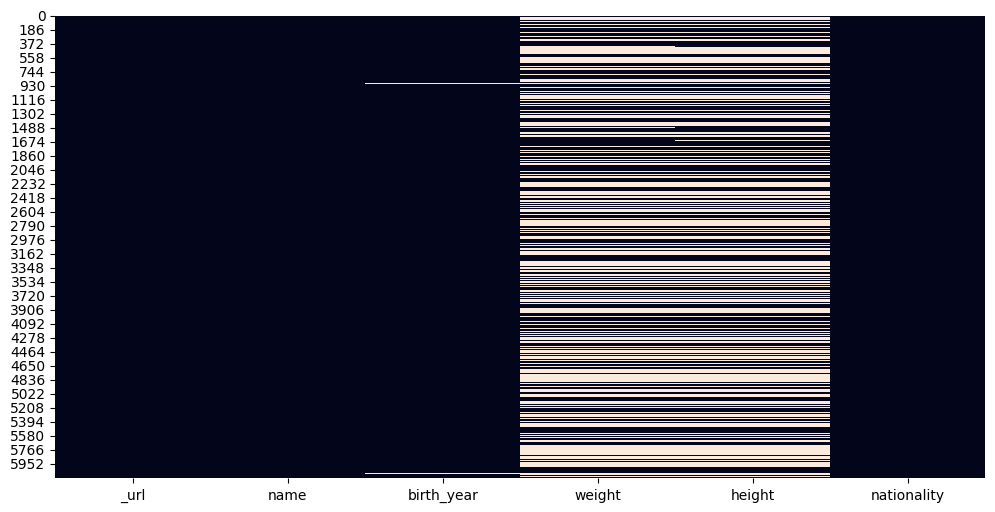

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(dataset_cyclists.isnull(), cbar=False, xticklabels=True, ax=ax)
plt.show()

it is possible to note that the following values are missing from the cyclist dataset:
- 13 years of birth
- 3056 weights
- 2991 heigths
- 1 nationality

### Checking for correct data type and value validity

In [15]:
# numerical feature
dataset_cyclists.select_dtypes(include="number")

,birth_year,weight,height
0,1964.0,NaN,NaN
1,1965.0,74.0,182.0
2,1996.0,69.0,189.0
3,1995.0,78.0,192.0
4,1997.0,55.0,171.0
...,...,...,...
6129,1966.0,NaN,NaN
6130,1998.0,75.0,188.0
6131,1973.0,NaN,NaN
6132,1985.0,58.0,170.0


In [16]:
numerical_dataset_cyclists = dataset_cyclists.select_dtypes(include="number")

In [17]:
numerical_dataset_cyclists.columns

Index(['birth_year', 'weight', 'height'], dtype='object')

In [18]:
# checking the correct type of the features
numerical_columns_to_check = ['birth_year', 'weight', 'height']

for column in numerical_columns_to_check:
    valid_values = dataset_cyclists[column].dropna().apply(lambda x: isinstance(x, (int, float))).value_counts()
    print(f"Column: {column}")
    print(valid_values)
    print("-" * 30) 


Column: birth_year
birth_year
True    6121
Name: count, dtype: int64
------------------------------
Column: weight
weight
True    3078
Name: count, dtype: int64
------------------------------
Column: height
height
True    3143
Name: count, dtype: int64
------------------------------


All numerical data types are correct

In [19]:
# checking "birth_year" values
wrong_data = dataset_cyclists[(dataset_cyclists['birth_year'] < 0) | (dataset_cyclists['birth_year'] > 2024)]
print(wrong_data)

Empty DataFrame
Columns: [_url, name, birth_year, weight, height, nationality]
Index: []


In [20]:
# checking "weight" values
wrong_data = dataset_cyclists[(dataset_cyclists['weight'] < 0)]
print(wrong_data)

Empty DataFrame
Columns: [_url, name, birth_year, weight, height, nationality]
Index: []


In [21]:
# checking "height" values
wrong_data = dataset_cyclists[(dataset_cyclists['height'] < 0)]
print(wrong_data)

Empty DataFrame
Columns: [_url, name, birth_year, weight, height, nationality]
Index: []


All numerical data values are correct

In [22]:
# non numerical feature 
dataset_cyclists.select_dtypes(exclude="number")

,_url,name,nationality
0,bruno-surra,Bruno Surra,Italy
1,gerard-rue,Gérard Rué,France
2,jan-maas,Jan Maas,Netherlands
3,nathan-van-hooydonck,Nathan Van Hooydonck,Belgium
4,jose-felix-parra,José Félix Parra,Spain
...,...,...,...
6129,juan-jose-martinez-diaz,Juan José Martínez,Spain
6130,inigo-elosegui,Iñigo Elosegui,Spain
6131,paolo-alberati,Paolo Alberati,Italy
6132,jackson-rodriguez,Jackson Rodríguez,Venezuela


In [23]:
non_numerical_dataset_cyclists = dataset_cyclists.select_dtypes(exclude="number")

In [24]:
non_numerical_dataset_cyclists.columns

Index(['_url', 'name', 'nationality'], dtype='object')

In [25]:
# checking the correct type of the features
non_numerical_columns_to_check = ['_url', 'name', 'nationality']

for column in non_numerical_columns_to_check:
    valid_values = dataset_cyclists[column].dropna().apply(lambda x: isinstance(x, (str))).value_counts()
    print(f"Column: {column}")
    print(valid_values)
    print("-" * 30) 


Column: _url
_url
True    6134
Name: count, dtype: int64
------------------------------
Column: name
name
True    6134
Name: count, dtype: int64
------------------------------
Column: nationality
nationality
True    6133
Name: count, dtype: int64
------------------------------


All non numerical data types are correct

In [26]:
# looking for duplicates in the dataset
duplicate_dataset_cy = dataset_cyclists[dataset_cyclists.duplicated(keep=False)]
duplicate_dataset_cy

,_url,name,birth_year,weight,height,nationality


***No duplicates*** are present in this dataset

### Data Visualization

In [27]:
dataset_cyclists.columns

Index(['_url', 'name', 'birth_year', 'weight', 'height', 'nationality'], dtype='object')

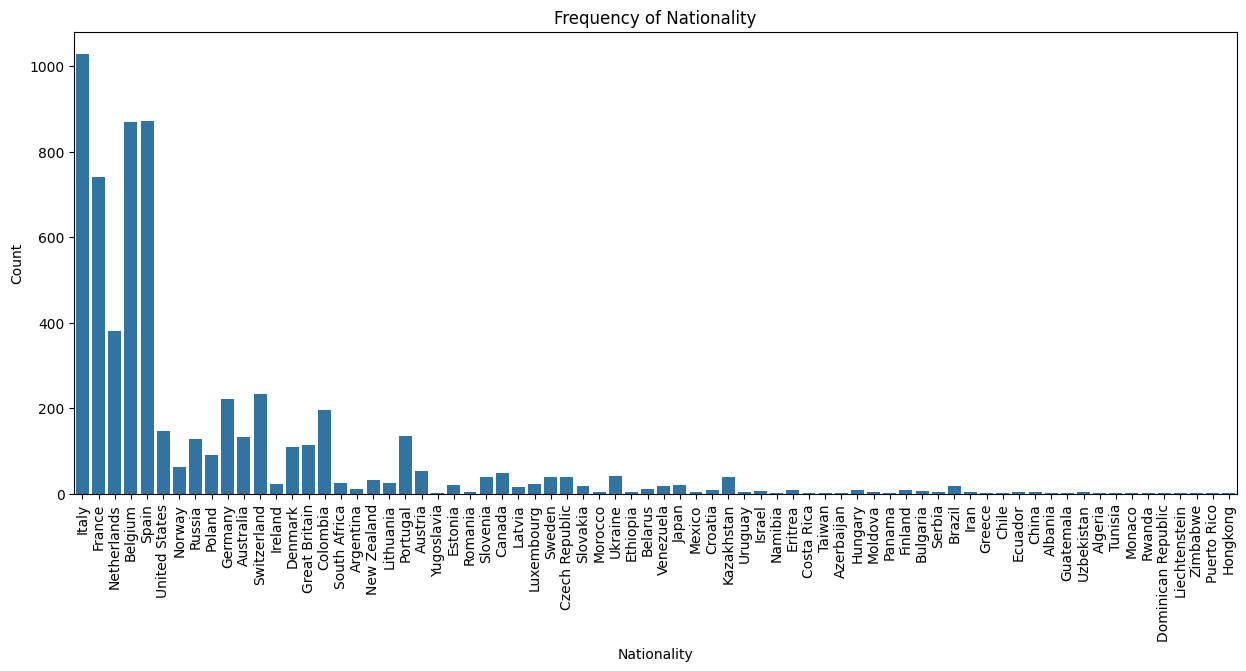

In [28]:
# displaying nationality of cyclists
plt.figure(figsize=(15, 6))

sns.countplot(x='nationality', data=dataset_cyclists)

plt.title('Frequency of Nationality')
plt.xlabel('Nationality')
plt.ylabel('Count')
plt.xticks(rotation=90)

plt.show()

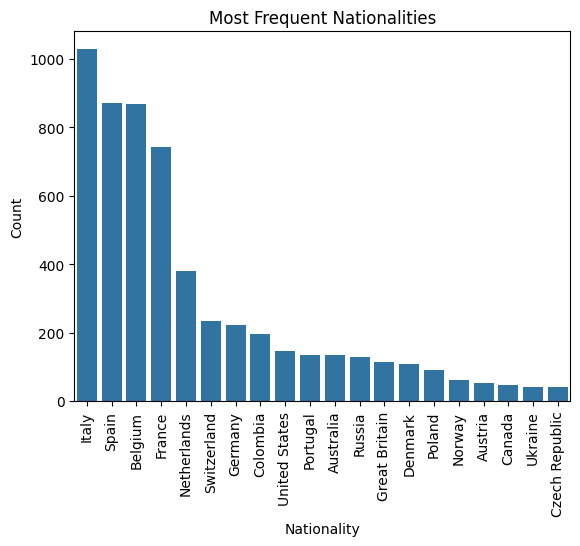

In [29]:
# most frequent nationalities
top_20_index = dataset_cyclists['nationality'].value_counts().nlargest(20).index
top_20_dataset = dataset_cyclists[dataset_cyclists['nationality'].isin(top_20_index)]

sns.countplot(x='nationality', data=top_20_dataset, order=top_20_index)

plt.title('Most Frequent Nationalities')
plt.xlabel('Nationality')
plt.ylabel('Count')
plt.xticks(rotation=90)

plt.show()


In [30]:
italian_cyclists = (dataset_cyclists["nationality"] == "Italy").sum()
print(italian_cyclists)

1029


It is interesting to note that the dataset includes cyclists from 72 different nationalities, with the Italian nationality being the most represented with 1029 italian cyclists followed from Spain, Belgium and France.

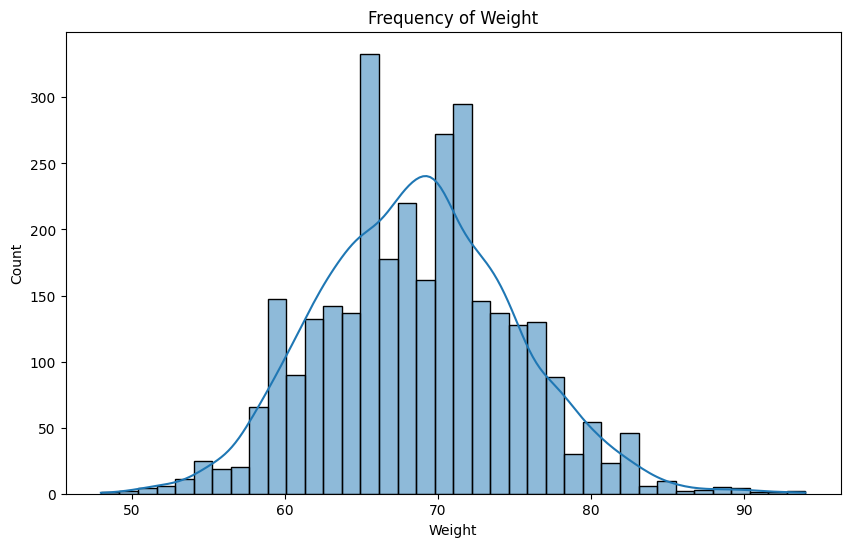

In [31]:
# displaying weight of cyclists
plt.figure(figsize=(10, 6))
sns.histplot(x='weight', data=dataset_cyclists, kde=True)

plt.title('Frequency of Weight')
plt.xlabel('Weight')
plt.ylabel('Count')

plt.show()

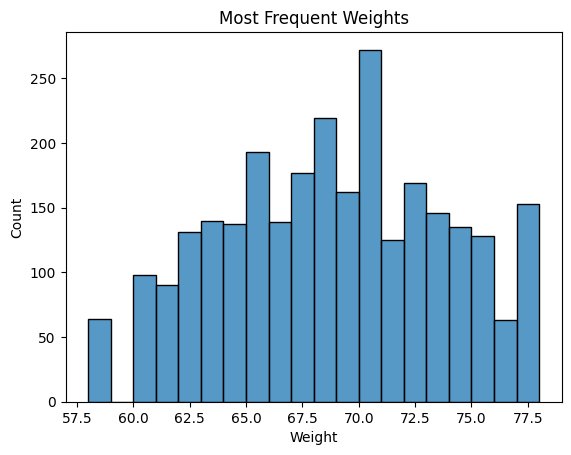

In [32]:
# most frequents weights
top_20_index = dataset_cyclists['weight'].value_counts().nlargest(20).index
top_20_dataset = dataset_cyclists[dataset_cyclists['weight'].isin(top_20_index)]

sns.histplot(x='weight', data=top_20_dataset)

plt.title('Most Frequent Weights')
plt.xlabel('Weight')
plt.ylabel('Count')

plt.show()


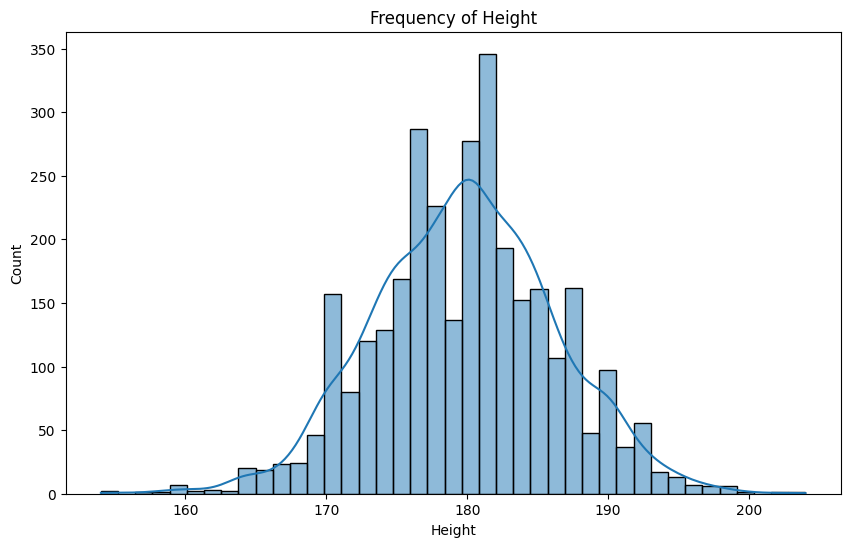

In [33]:
# displaying height of cyclists
plt.figure(figsize=(10, 6))

sns.histplot(x='height', data=dataset_cyclists, kde=True)

plt.title('Frequency of Height')
plt.xlabel('Height')
plt.ylabel('Count')

plt.show()

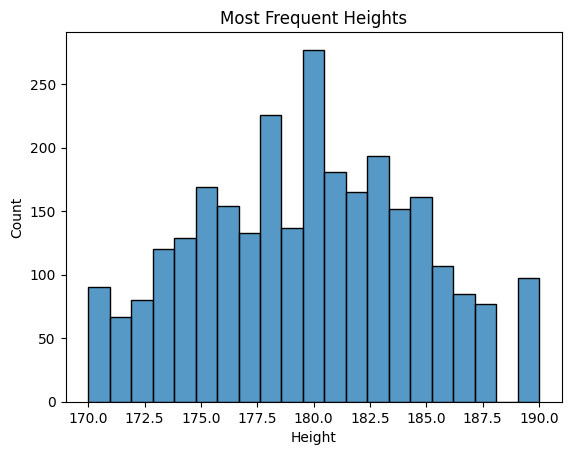

In [34]:
# most frequents heights
top_20_index = dataset_cyclists['height'].value_counts().nlargest(20).index
top_20_dataset = dataset_cyclists[dataset_cyclists['height'].isin(top_20_index)]

sns.histplot(x='height', data=top_20_dataset)

plt.title('Most Frequent Heights')
plt.xlabel('Height')
plt.ylabel('Count')

plt.show()


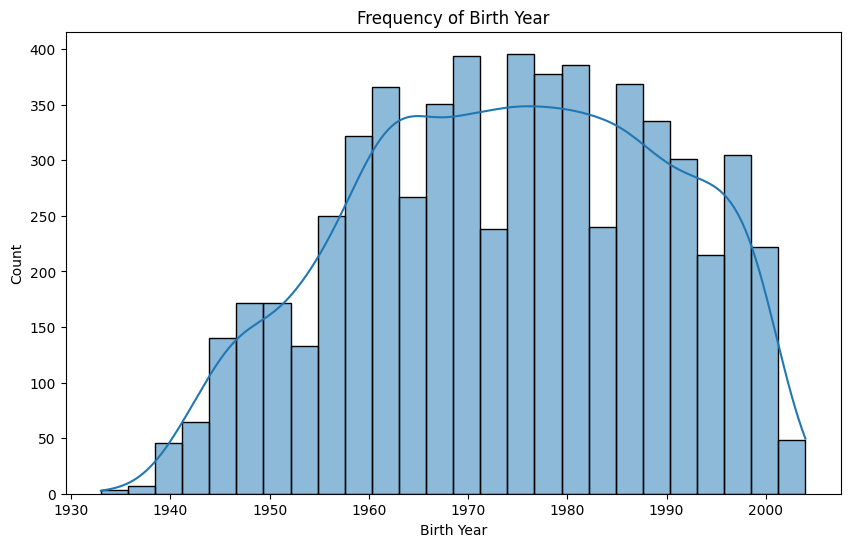

In [35]:
# displaying birth year of cyclists
copy_dataset_cyclists = dataset_cyclists.dropna(subset=['birth_year']).copy() 
copy_dataset_cyclists['birth_year'] = copy_dataset_cyclists['birth_year'].astype(int)

plt.figure(figsize=(10, 6))
sns.histplot(x='birth_year', data=copy_dataset_cyclists, kde=True)

plt.title('Frequency of Birth Year')
plt.xlabel('Birth Year')
plt.ylabel('Count')

plt.show()

In [36]:
# cyclist with the oldest date of birth
oldest_cyclist = copy_dataset_cyclists.loc[copy_dataset_cyclists['birth_year'].idxmin()]

# cyclist with the youngest date of birth
youngest_cyclist = copy_dataset_cyclists.loc[copy_dataset_cyclists['birth_year'].idxmax()]

print("Older cyclist:")
print(oldest_cyclist)

print("\nYounger cyclist:")
print(youngest_cyclist)


Older cyclist:
_url           rik-van-looy
name           Rik Van Looy
birth_year             1933
weight                 73.0
height                178.0
nationality         Belgium
Name: 398, dtype: object

Younger cyclist:
_url            joshua-tarling
name           Joshua  Tarling
birth_year                2004
weight                    78.0
height                   194.0
nationality      Great Britain
Name: 806, dtype: object


We can observe that the age of the cyclists spans a range of approximately 60 years. The oldest, **Rik Van Looy** was born in 1933 and the youngest **Joshua Tarling** who was born in 2004

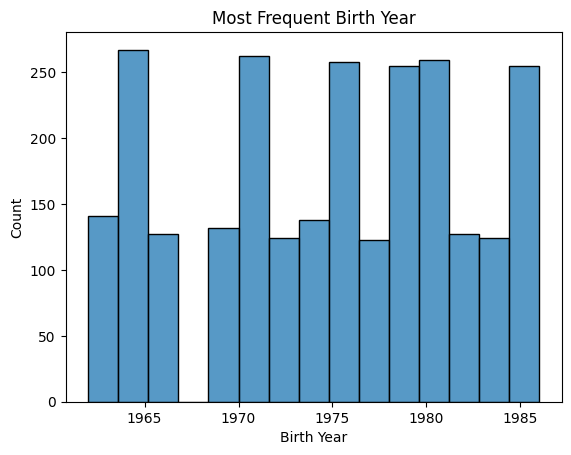

In [37]:
# most frequent birth year
top_20_index = copy_dataset_cyclists['birth_year'].value_counts().nlargest(20).index
top_20_dataset = copy_dataset_cyclists[copy_dataset_cyclists['birth_year'].isin(top_20_index)]

sns.histplot(x='birth_year', data=top_20_dataset)

plt.title('Most Frequent Birth Year')
plt.xlabel('Birth Year')
plt.ylabel('Count')

plt.show()


### Correlation

In [38]:
dataset_cyclists_numerical = dataset_cyclists.select_dtypes(include=[float, int])

In [39]:
dataset_cyclists_numerical.columns

Index(['birth_year', 'weight', 'height'], dtype='object')

<Axes: >

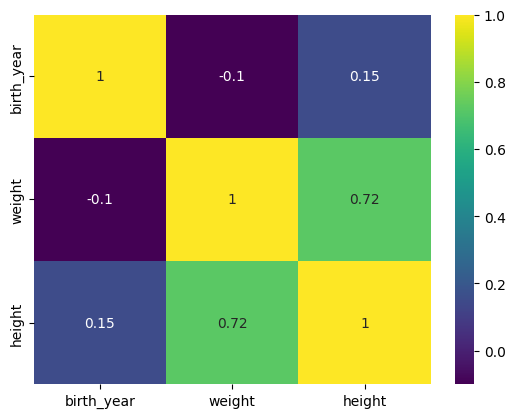

In [40]:
# Correlation matrix
correlation_cyclists = dataset_cyclists_numerical.corr('pearson')
sns.heatmap(correlation_cyclists.round(2),annot=True, cmap='viridis')

#### As was possible to imagine weight and height of the cyclists turn out to be strongly correlated unlike date of birth

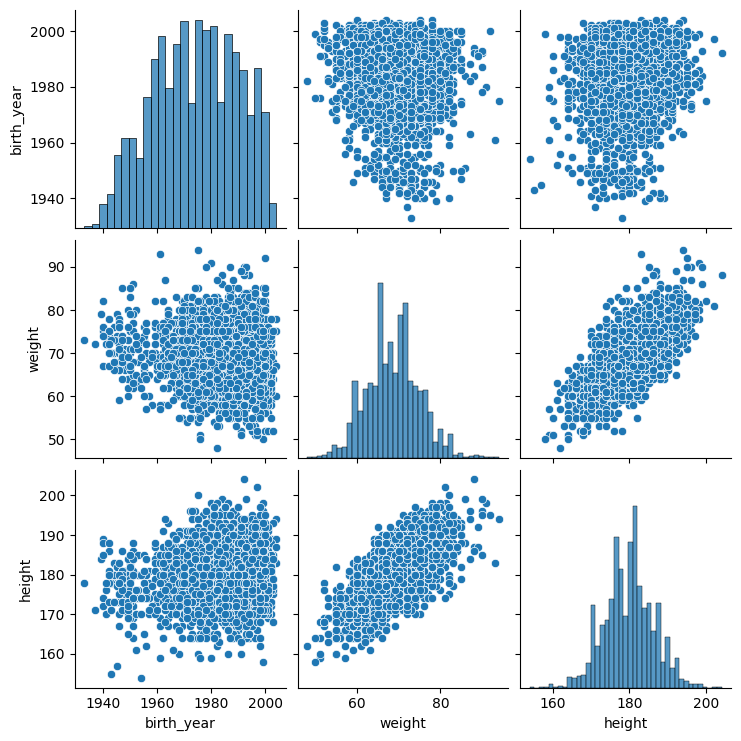

In [41]:
# generic pairplot
sns.pairplot(dataset_cyclists)

nationality
Italy      1029
Spain       872
Belgium     869
Name: count, dtype: int64

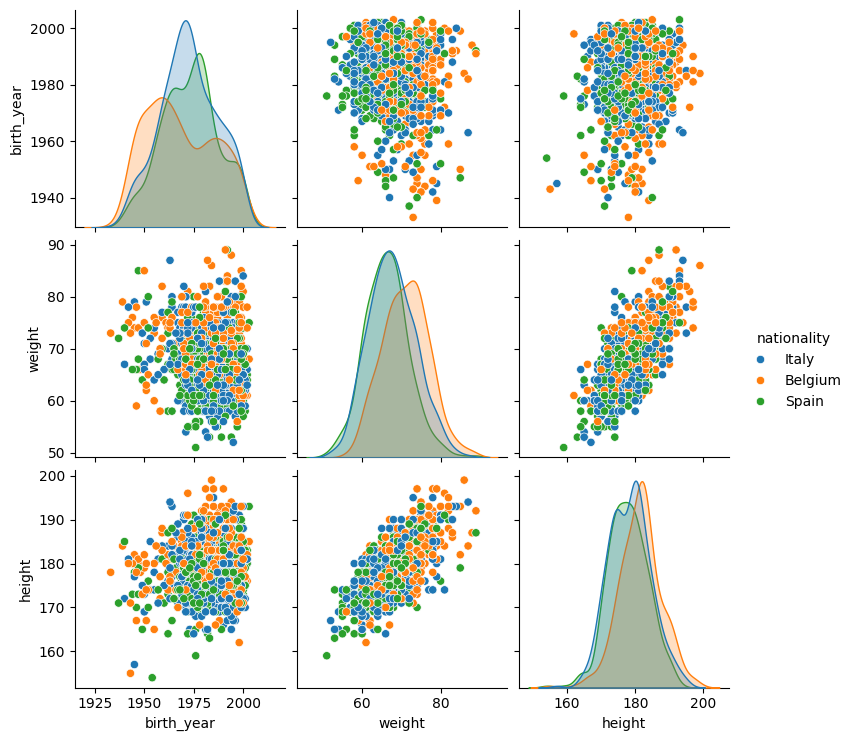

In [42]:
# selecting the 3 most frequent nationalities
top_nationalities = dataset_cyclists["nationality"].value_counts().head(3).index

# filtering the dataset
filtered_dataset = dataset_cyclists[dataset_cyclists["nationality"].isin(top_nationalities)]

sns.pairplot(filtered_dataset, hue="nationality")
dataset_cyclists["nationality"].value_counts().head(3)

<Axes: xlabel='weight', ylabel='height'>

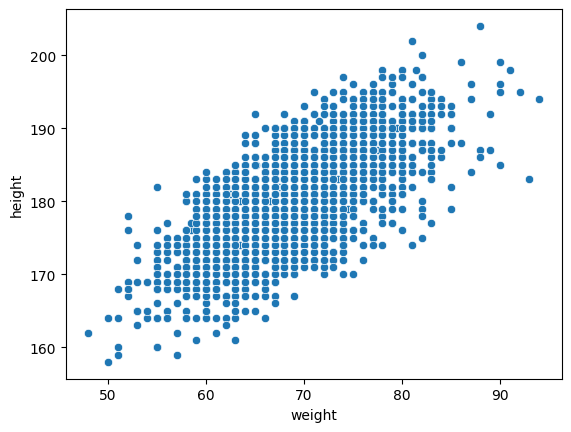

In [43]:
sns.scatterplot(dataset_cyclists, x=dataset_cyclists['weight'], y=dataset_cyclists['height'])

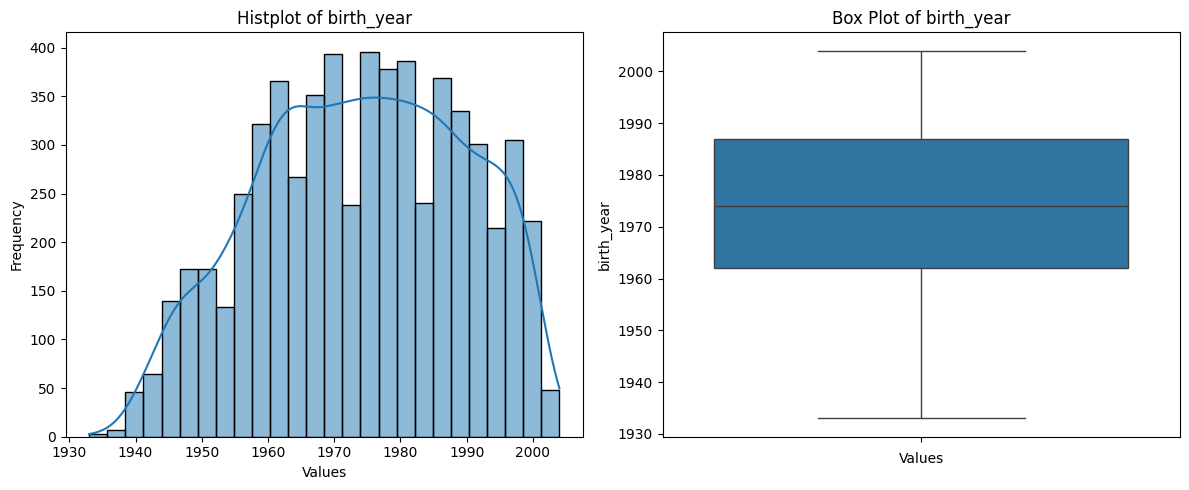

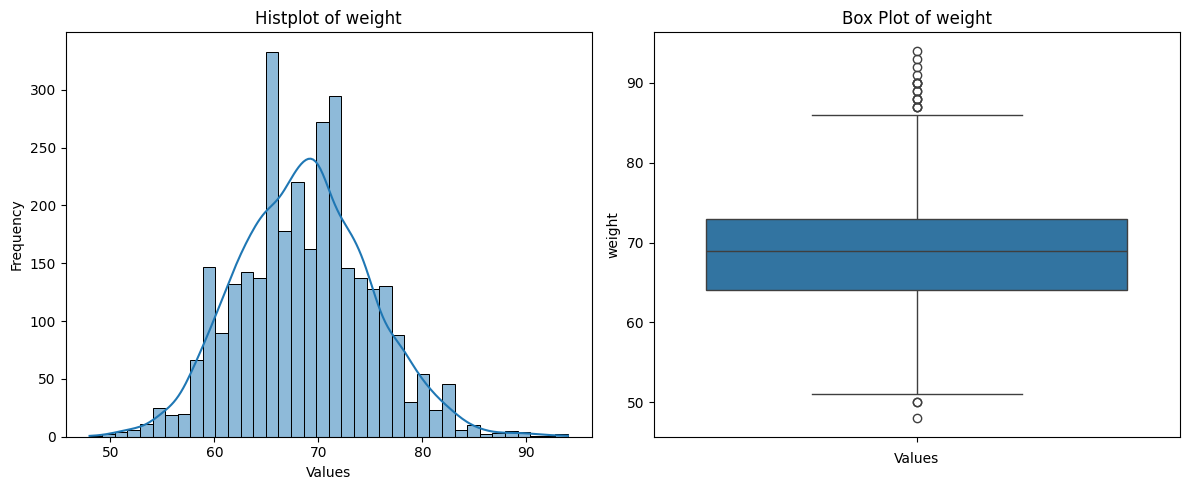

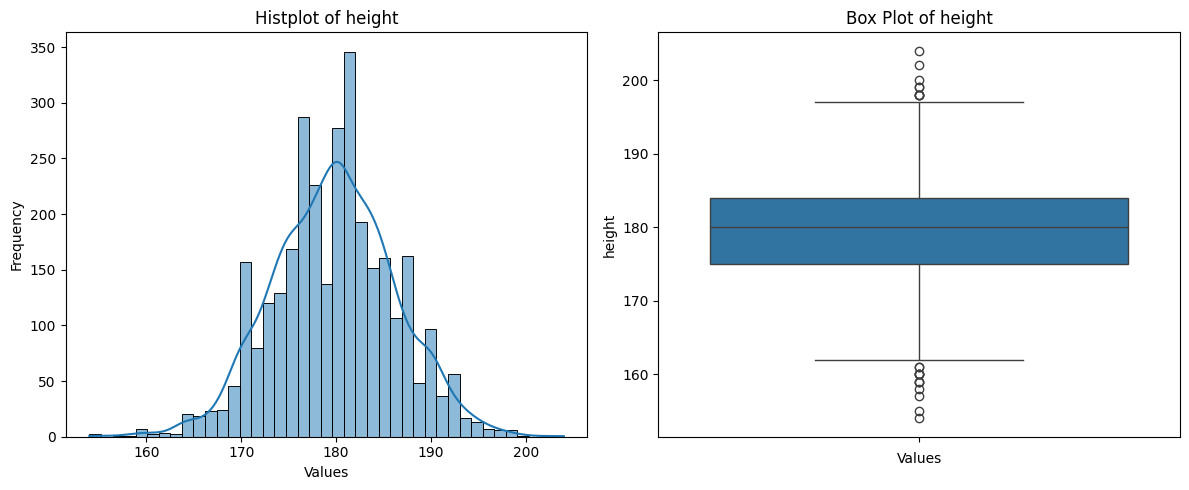

In [44]:
# displaying the distribution of numerical features with their associated boxplots in order to have a general overview

columns_to_select  = dataset_cyclists.select_dtypes(include=['number']).columns


for col in columns_to_select:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 
    
    # histplot
    sns.histplot(dataset_cyclists[col], kde=True, ax=axes[0], edgecolor='black')
    axes[0].set_title(f'Histplot of {col}')
    axes[0].set_xlabel('Values')
    axes[0].set_ylabel('Frequency')
    
    # box plot
    sns.boxplot(y=dataset_cyclists[col], ax=axes[1])
    axes[1].set_title(f'Box Plot of {col}')
    axes[1].set_xlabel('Values')
    
    # showing graphs
    plt.tight_layout()
    plt.show()

### Normalizing the data: for this purpose, we are going to use the Standard Scaling 
**Standard scaling**

Data are standardized; removal of mean and rescaling to have standard deviation equal to 1.
$$
x = \dfrac{x - \mu}{\sigma}.
$$

In [45]:
normalized_dataset_c, normalization_scalers_dataset_c = center_and_scale(dataset_cyclists_numerical)

In [46]:
# to check the result of normalization
normalized_dataset_c.describe()

,birth_year,weight,height
count,6.121000e+03,3.078000e+03,3.143000e+03
mean,-6.681725e-15,4.818902e-16,-1.056884e-15
std,1.000082e+00,1.000162e+00,1.000159e+00
min,-2.643903e+00,-3.254805e+00,-4.007056e+00
25%,-7.770983e-01,-7.339890e-01,-7.474122e-01
50%,-4.627338e-03,5.376594e-02,2.869344e-02
75%,8.322162e-01,6.839699e-01,6.495779e-01
max,1.926550e+00,3.992541e+00,3.754000e+00


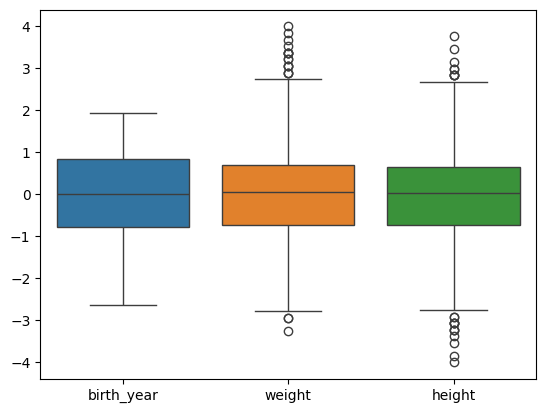

In [47]:
# normalized dataset
sns.boxplot(normalized_dataset_c)
plt.show()

From the boxplot, it appears that both weight and height may have outliers at first glance.

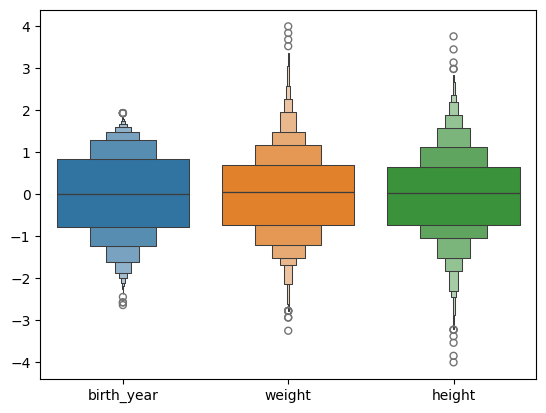

In [48]:
# normalized dataset
sns.boxenplot(normalized_dataset_c)
plt.show()

## Races Dataset

In [49]:
dataset_races = pd.read_csv("../dataset/dataset/races.csv")

### General Overview of the Races Dataset

In [50]:
dataset_races.head()

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,date,position,cyclist,cyclist_age,is_tarmac,is_cobbled,is_gravel,cyclist_team,delta
0,tour-de-france/1978/stage-6,Tour de France,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,1978-07-05 04:02:24,0,sean-kelly,22.0,True,False,False,vini-ricordi-pinarello-sidermec-1986,0.0
1,tour-de-france/1978/stage-6,Tour de France,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,1978-07-05 04:02:24,1,gerrie-knetemann,27.0,True,False,False,norway-1987,0.0
2,tour-de-france/1978/stage-6,Tour de France,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,1978-07-05 04:02:24,2,rene-bittinger,24.0,True,False,False,NaN,0.0
3,tour-de-france/1978/stage-6,Tour de France,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,1978-07-05 04:02:24,3,joseph-bruyere,30.0,True,False,False,navigare-blue-storm-1993,0.0
4,tour-de-france/1978/stage-6,Tour de France,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,1978-07-05 04:02:24,4,sven-ake-nilsson,27.0,True,False,False,spain-1991,0.0


In [51]:
dataset_races.shape

(589865, 18)

In [52]:
dataset_races.describe()

,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,position,cyclist_age,delta
count,589388.000000,251086.000000,589865.000000,442820.000000,441671.000000,589865.000000,29933.000000,589865.000000,589752.000000,589865.000000
mean,89.221635,74.601547,166776.180584,2330.469215,2.611611,1101.161178,21.731768,74.219491,28.486208,418.292794
std,54.435330,100.947962,64545.605664,1375.710722,1.491741,380.586928,5.884761,48.404023,3.855631,842.961596
min,18.000000,6.000000,1000.000000,2.000000,1.000000,115.000000,10.000000,0.000000,13.000000,-6906.000000
25%,50.000000,16.000000,152500.000000,1309.000000,1.000000,844.000000,17.000000,32.000000,26.000000,10.000000
50%,80.000000,60.000000,178200.000000,2255.000000,2.000000,988.000000,22.000000,70.000000,28.000000,156.000000
75%,100.000000,100.000000,203500.000000,3273.000000,4.000000,1309.000000,26.000000,112.000000,31.000000,624.000000
max,350.000000,800.000000,338000.000000,6974.000000,5.000000,2047.000000,36.000000,209.000000,56.000000,61547.000000


In [53]:
dataset_races.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 589865 entries, 0 to 589864
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   _url                 589865 non-null  object 
 1   name                 589865 non-null  object 
 2   points               589388 non-null  float64
 3   uci_points           251086 non-null  float64
 4   length               589865 non-null  float64
 5   climb_total          442820 non-null  float64
 6   profile              441671 non-null  float64
 7   startlist_quality    589865 non-null  int64  
 8   average_temperature  29933 non-null   float64
 9   date                 589865 non-null  object 
 10  position             589865 non-null  int64  
 11  cyclist              589865 non-null  object 
 12  cyclist_age          589752 non-null  float64
 13  is_tarmac            589865 non-null  bool   
 14  is_cobbled           589865 non-null  bool   
 15  is_gravel        

In [54]:
dataset_races.columns

Index(['_url', 'name', 'points', 'uci_points', 'length', 'climb_total',
       'profile', 'startlist_quality', 'average_temperature', 'date',
       'position', 'cyclist', 'cyclist_age', 'is_tarmac', 'is_cobbled',
       'is_gravel', 'cyclist_team', 'delta'],
      dtype='object')

This dataset is also a **Data Matrix** and consists of:
- **589865 rows** corresponding to the races 
- **18 columns** corresponding to the following features for each race: *'_url', 'name', 'points', 'uci_points', 'length', 'climb_total',
       'profile', 'startlist_quality', 'average_temperature', 'date',
       'position', 'cyclist', 'cyclist_age', 'is_tarmac', 'is_cobbled',
       'is_gravel', 'cyclist_team', 'delta'*

In [55]:
# data types in races dataset
dataset_races.dtypes

_url                    object
name                    object
points                 float64
uci_points             float64
length                 float64
climb_total            float64
profile                float64
startlist_quality        int64
average_temperature    float64
date                    object
position                 int64
cyclist                 object
cyclist_age            float64
is_tarmac                 bool
is_cobbled                bool
is_gravel                 bool
cyclist_team            object
delta                  float64
dtype: object

- #### _url is a **Nominal** attribute: 
It represents the race's url where information pertaining to the race can be found.
- #### name is a **Nominal** attribute:
 It represents the race name.
- #### points is a **Ordinal** attribute:
 It represent the prestige of a race. The greater the value of points the greater the prestige of the races.
- #### uci_points is a **Ordinal** attribute:
 It represents an alternative to points.
- #### length is a **Numerical** attribute:
 It represents the length in meters of the race.
- #### climb_total is a **Numerical** attribute:
 It represents the total meters climbed during the race.
- #### profile is a **Ordinal** attribute:
 It represents the profile of the race in order of increasing difficult from 1.0 (easier) to 5.0 (harder).
- #### startlist_quality is a **Numerical** attribute:
 It represents how strong are the participants at the race. The higher the value the stronger the cyclists are.
- #### average_temperature is a **Numerical** attribute:
 It represents the average temperature of the race.
- #### date is a **Numerical** attribute:
 It represents the race date.
- #### position is a **Ordinal** attribute:
 It represents the position the cyclist arrived in.
- #### cyclist is a **Nominal** attribute:
 It represents the name of the cyclist.
- #### cyclist_age is a **Numerical** attribute:
 It represents the age of the cyclist.
- #### is_tarmac is a **Symmetric Binary** attribute:
 It represents if the type of surface of the race is tarmac or not.
- #### is_cobbled is a **Symmetric Binary** attribute:
 It represents if the type of surface of the race is cobbled or not.
- #### is_gravel is a **Symmetric Binary** attribute:
 It represents if the type of surface of the race is gravel or not.
- #### cyclist_team is a **Nominal** attribute:
 It represents the name of the cyclist's team.
- #### delta is a **Numerical** attribute:
 It represents how many seconds ater the first placed did the cyclist get to the finish.

In [56]:
# to take a look at each column
dataset_races["_url"],dataset_races["name"],dataset_races["points"],\
    dataset_races["uci_points"],dataset_races["length"],dataset_races["climb_total"],\
    dataset_races["profile"],dataset_races["startlist_quality"],dataset_races["average_temperature"],\
    dataset_races["date"],dataset_races["position"],dataset_races["cyclist"],\
    dataset_races["cyclist_age"],dataset_races["is_tarmac"],dataset_races["is_cobbled"],\
    dataset_races["is_gravel"],dataset_races["cyclist_team"],dataset_races["delta"]
    

(0         tour-de-france/1978/stage-6
 1         tour-de-france/1978/stage-6
 2         tour-de-france/1978/stage-6
 3         tour-de-france/1978/stage-6
 4         tour-de-france/1978/stage-6
                      ...             
 589860     giro-d-italia/2010/stage-1
 589861     giro-d-italia/2010/stage-1
 589862     giro-d-italia/2010/stage-1
 589863     giro-d-italia/2010/stage-1
 589864     giro-d-italia/2010/stage-1
 Name: _url, Length: 589865, dtype: object,
 0         Tour de France
 1         Tour de France
 2         Tour de France
 3         Tour de France
 4         Tour de France
                ...      
 589860     Giro d'Italia
 589861     Giro d'Italia
 589862     Giro d'Italia
 589863     Giro d'Italia
 589864     Giro d'Italia
 Name: name, Length: 589865, dtype: object,
 0         100.0
 1         100.0
 2         100.0
 3         100.0
 4         100.0
           ...  
 589860     80.0
 589861     80.0
 589862     80.0
 589863     80.0
 589864     80.0
 Name: poi

In [57]:
# to see how many unique values each feature has (this command also counts the missing value (Nan) as a unique value)
features = ['_url', 'name', 'points', 'uci_points', 'length', 'climb_total',
       'profile', 'startlist_quality', 'average_temperature', 'date',
       'position', 'cyclist', 'cyclist_age', 'is_tarmac', 'is_cobbled',
       'is_gravel', 'cyclist_team', 'delta']

for feature in features:
    unique_count = len(dataset_races[feature].unique())
    print(f"Feature '{feature}' has {unique_count} unique values")

Feature '_url' has 5281 unique values
Feature 'name' has 61 unique values
Feature 'points' has 15 unique values
Feature 'uci_points' has 21 unique values
Feature 'length' has 1280 unique values
Feature 'climb_total' has 2118 unique values
Feature 'profile' has 6 unique values
Feature 'startlist_quality' has 697 unique values
Feature 'average_temperature' has 28 unique values
Feature 'date' has 140509 unique values
Feature 'position' has 210 unique values
Feature 'cyclist' has 6095 unique values
Feature 'cyclist_age' has 30 unique values
Feature 'is_tarmac' has 2 unique values
Feature 'is_cobbled' has 1 unique values
Feature 'is_gravel' has 1 unique values
Feature 'cyclist_team' has 92 unique values
Feature 'delta' has 2836 unique values


In [58]:
dataset_races[["is_cobbled","is_gravel"]]

,is_cobbled,is_gravel
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
589860,False,False
589861,False,False
589862,False,False
589863,False,False


#### We can see that the features “is_cobbled” and “is_gravel” take **only one value**, specifically the value *False*.

In [59]:
# to see how many and what are the unique feature values (this command instead does not count the missing value (NaN))
dataset_races["_url"].value_counts(),dataset_races["name"].value_counts(),dataset_races["points"].value_counts(),\
    dataset_races["uci_points"].value_counts(),dataset_races["length"].value_counts(),dataset_races["climb_total"].value_counts(),\
    dataset_races["profile"].value_counts(),dataset_races["startlist_quality"].value_counts(),dataset_races["average_temperature"].value_counts(),\
    dataset_races["date"].value_counts(),dataset_races["position"].value_counts(),dataset_races["cyclist"].value_counts(),\
    dataset_races["cyclist_age"].value_counts(),dataset_races["is_tarmac"].value_counts(),dataset_races["is_cobbled"].value_counts(),\
    dataset_races["is_gravel"].value_counts(),dataset_races["cyclist_team"].value_counts(),dataset_races["delta"].value_counts()
    

(_url
 tour-de-france/1986/stage-1     210
 tour-de-france/1986/prologue    210
 tour-de-france/1987/prologue    207
 tour-de-france/1987/stage-1     206
 giro-d-italia/2011/stage-2      206
                                ... 
 tour-de-suisse/1972/stage-6b      1
 il-lombardia/1972/result          1
 giro-d-italia/2001/stage-14       1
 tour-de-suisse/1972/stage-7       1
 tour-de-suisse/1972/stage-2       1
 Name: count, Length: 5281, dtype: int64,
 name
 Tour de France                     145500
 Giro d'Italia                       95581
 Vuelta a España                     89222
 Tour de Suisse                      33682
 Paris - Nice                        32362
                                     ...  
 E3 Saxo Classic                       101
 E3 BinckBank Classic                   99
 E3 Prijs Vlaanderen - Harelbeke        98
 Clásica Ciclista San Sebastian         84
 Clásica San Sebastián                  52
 Name: count, Length: 61, dtype: int64,
 points
 80.0     198878
 

### Missing values inspection

In [60]:
dataset_races.isnull().sum()

_url                        0
name                        0
points                    477
uci_points             338779
length                      0
climb_total            147045
profile                148194
startlist_quality           0
average_temperature    559932
date                        0
position                    0
cyclist                     0
cyclist_age               113
is_tarmac                   0
is_cobbled                  0
is_gravel                   0
cyclist_team           159161
delta                       0
dtype: int64

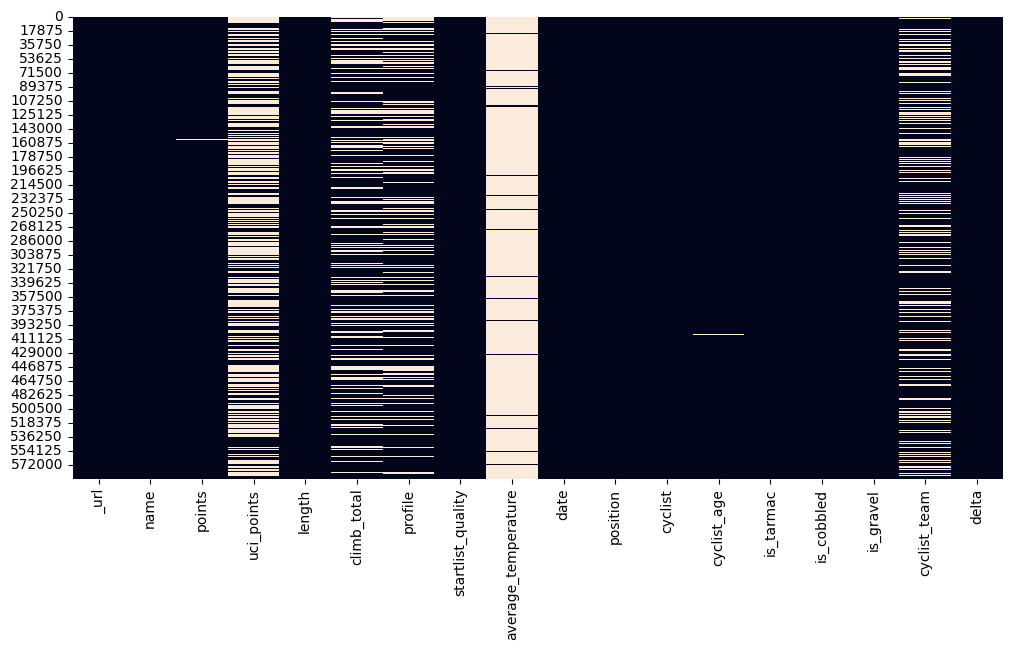

In [61]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(dataset_races.isnull(), cbar=False, xticklabels=True, ax=ax)
plt.show()

It is possible to note that the following values are missing from the cyclist dataset:
- 447 points
- 338779 uci points
- 147045 climb total
- 148194 profile
- 559932 average temperature
- 113 cyclist age
- 159161 cyclist team

We can see that the "average_temperature" column is almost completely absent, about 95% of the values are missing.

### Checking for correct data type and value validity

In [62]:
# numerical feature
dataset_races.select_dtypes(include="number")

,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,position,cyclist_age,delta
0,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,0,22.0,0.0
1,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,1,27.0,0.0
2,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,2,24.0,0.0
3,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,3,30.0,0.0
4,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,4,27.0,0.0
...,...,...,...,...,...,...,...,...,...,...
589860,80.0,16.0,8400.0,60.0,1.0,878,NaN,192,25.0,80.0
589861,80.0,16.0,8400.0,60.0,1.0,878,NaN,193,28.0,82.0
589862,80.0,16.0,8400.0,60.0,1.0,878,NaN,194,24.0,83.0
589863,80.0,16.0,8400.0,60.0,1.0,878,NaN,195,38.0,90.0


In [63]:
numerical_dataset_races = dataset_races.select_dtypes(include="number")

In [64]:
numerical_dataset_races.columns

Index(['points', 'uci_points', 'length', 'climb_total', 'profile',
       'startlist_quality', 'average_temperature', 'position', 'cyclist_age',
       'delta'],
      dtype='object')

In [65]:
# checking the correct type of the features
numerical_columns_to_check = ['points', 'uci_points', 'length', 'climb_total', 'profile',
       'startlist_quality', 'average_temperature', 'position', 'cyclist_age','delta']

for column in numerical_columns_to_check:
    valid_values = dataset_races[column].dropna().apply(lambda x: isinstance(x, (int, float))).value_counts()
    print(f"Column: {column}")
    print(valid_values)
    print("-" * 30) 


Column: points
points
True    589388
Name: count, dtype: int64
------------------------------
Column: uci_points
uci_points
True    251086
Name: count, dtype: int64
------------------------------
Column: length
length
True    589865
Name: count, dtype: int64
------------------------------
Column: climb_total
climb_total
True    442820
Name: count, dtype: int64
------------------------------
Column: profile
profile
True    441671
Name: count, dtype: int64
------------------------------
Column: startlist_quality
startlist_quality
True    589865
Name: count, dtype: int64
------------------------------
Column: average_temperature
average_temperature
True    29933
Name: count, dtype: int64
------------------------------
Column: position
position
True    589865
Name: count, dtype: int64
------------------------------
Column: cyclist_age
cyclist_age
True    589752
Name: count, dtype: int64
------------------------------
Column: delta
delta
True    589865
Name: count, dtype: int64
------------

All numerical data types are correct

In [66]:
# checking "points" values
wrong_data = dataset_races[(dataset_races['points'] < 0)]
print(wrong_data)

Empty DataFrame
Columns: [_url, name, points, uci_points, length, climb_total, profile, startlist_quality, average_temperature, date, position, cyclist, cyclist_age, is_tarmac, is_cobbled, is_gravel, cyclist_team, delta]
Index: []


In [67]:
# checking "uci_points" values
wrong_data = dataset_races[(dataset_races['uci_points'] < 0)]
print(wrong_data)

Empty DataFrame
Columns: [_url, name, points, uci_points, length, climb_total, profile, startlist_quality, average_temperature, date, position, cyclist, cyclist_age, is_tarmac, is_cobbled, is_gravel, cyclist_team, delta]
Index: []


In [68]:
# checking "length" values
wrong_data = dataset_races[(dataset_races['length'] < 0)]
print(wrong_data)

Empty DataFrame
Columns: [_url, name, points, uci_points, length, climb_total, profile, startlist_quality, average_temperature, date, position, cyclist, cyclist_age, is_tarmac, is_cobbled, is_gravel, cyclist_team, delta]
Index: []


In [69]:
# checking "climb_total" values
wrong_data = dataset_races[(dataset_races['climb_total'] < 0)]
print(wrong_data)

Empty DataFrame
Columns: [_url, name, points, uci_points, length, climb_total, profile, startlist_quality, average_temperature, date, position, cyclist, cyclist_age, is_tarmac, is_cobbled, is_gravel, cyclist_team, delta]
Index: []


In [70]:
# checking "profile" values
wrong_data = dataset_races[(dataset_races['profile'] < 0)]
print(wrong_data)

Empty DataFrame
Columns: [_url, name, points, uci_points, length, climb_total, profile, startlist_quality, average_temperature, date, position, cyclist, cyclist_age, is_tarmac, is_cobbled, is_gravel, cyclist_team, delta]
Index: []


In [71]:
# checking "startlist_quality" values
wrong_data = dataset_races[(dataset_races['startlist_quality'] < 0)]
print(wrong_data)

Empty DataFrame
Columns: [_url, name, points, uci_points, length, climb_total, profile, startlist_quality, average_temperature, date, position, cyclist, cyclist_age, is_tarmac, is_cobbled, is_gravel, cyclist_team, delta]
Index: []


In [72]:
# checking "average_temperature" values
wrong_data = dataset_races[(dataset_races['average_temperature'] < 0)]
print(wrong_data)

Empty DataFrame
Columns: [_url, name, points, uci_points, length, climb_total, profile, startlist_quality, average_temperature, date, position, cyclist, cyclist_age, is_tarmac, is_cobbled, is_gravel, cyclist_team, delta]
Index: []


In [73]:
# checking "position" values
wrong_data = dataset_races[(dataset_races['position'] < 0)]
print(wrong_data)

Empty DataFrame
Columns: [_url, name, points, uci_points, length, climb_total, profile, startlist_quality, average_temperature, date, position, cyclist, cyclist_age, is_tarmac, is_cobbled, is_gravel, cyclist_team, delta]
Index: []


In [74]:
# checking "cyclist_age" values
wrong_data = dataset_races[(dataset_races['cyclist_age'] < 0)]
print(wrong_data)

Empty DataFrame
Columns: [_url, name, points, uci_points, length, climb_total, profile, startlist_quality, average_temperature, date, position, cyclist, cyclist_age, is_tarmac, is_cobbled, is_gravel, cyclist_team, delta]
Index: []


In [75]:
# checking "delta" values
wrong_data = dataset_races[(dataset_races['delta'] < 0)]
print(wrong_data)

                                 _url             name  points  uci_points  \
70651   vuelta-a-espana/1992/stage-19  Vuelta a España    80.0         NaN   
70652   vuelta-a-espana/1992/stage-19  Vuelta a España    80.0         NaN   
70653   vuelta-a-espana/1992/stage-19  Vuelta a España    80.0         NaN   
70654   vuelta-a-espana/1992/stage-19  Vuelta a España    80.0         NaN   
70655   vuelta-a-espana/1992/stage-19  Vuelta a España    80.0         NaN   
...                               ...              ...     ...         ...   
229670       paris-nice/1990/stage-7a     Paris - Nice    50.0         NaN   
229671       paris-nice/1990/stage-7a     Paris - Nice    50.0         NaN   
229672       paris-nice/1990/stage-7a     Paris - Nice    50.0         NaN   
413492   tour-de-france/2003/stage-12   Tour de France   100.0         NaN   
520735    tour-de-suisse/1993/stage-4   Tour de Suisse    50.0         NaN   

          length  climb_total  profile  startlist_quality  \
70

In [76]:
wrong_data

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,date,position,cyclist,cyclist_age,is_tarmac,is_cobbled,is_gravel,cyclist_team,delta
70651,vuelta-a-espana/1992/stage-19,Vuelta a España,80.0,NaN,37900.0,294.0,NaN,1033,NaN,1992-05-15 00:02:23,10,johan-bruyneel,28.0,True,False,False,ville-de-charleroi-new-systems-2000,-2635.0
70652,vuelta-a-espana/1992/stage-19,Vuelta a España,80.0,NaN,37900.0,294.0,NaN,1033,NaN,1992-05-15 00:02:20,11,raul-alcala,28.0,True,False,False,team-volksbank-2008,-2638.0
70653,vuelta-a-espana/1992/stage-19,Vuelta a España,80.0,NaN,37900.0,294.0,NaN,1033,NaN,1992-05-15 00:03:57,12,joachim-halupczok,24.0,True,False,False,NaN,-2541.0
70654,vuelta-a-espana/1992/stage-19,Vuelta a España,80.0,NaN,37900.0,294.0,NaN,1033,NaN,1992-05-15 00:03:56,13,djamolidine-abduzhaparov,28.0,True,False,False,south-africa-2022,-2542.0
70655,vuelta-a-espana/1992/stage-19,Vuelta a España,80.0,NaN,37900.0,294.0,NaN,1033,NaN,1992-05-15 00:03:53,14,guido-bontempi,32.0,True,False,False,south-africa-2022,-2545.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229670,paris-nice/1990/stage-7a,Paris - Nice,50.0,NaN,102000.0,NaN,NaN,995,NaN,1990-03-11 00:55:03,7,laurent-jalabert,22.0,True,False,False,kazakhstan-2022,-5562.0
229671,paris-nice/1990/stage-7a,Paris - Nice,50.0,NaN,102000.0,NaN,NaN,995,NaN,1990-03-11 00:55:03,8,claudio-chiappucci,27.0,True,False,False,csf-group-navigare-2008,-5562.0
229672,paris-nice/1990/stage-7a,Paris - Nice,50.0,NaN,102000.0,NaN,NaN,995,NaN,1990-03-11 00:32:39,9,jean-claude-colotti,29.0,True,False,False,jolly-ceramica-1977,-6906.0
413492,tour-de-france/2003/stage-12,Tour de France,100.0,NaN,47000.0,712.0,2.0,1688,NaN,2003-07-18 00:09:35,104,leonardo-bertagnolli,25.0,True,False,False,team-saxo-bank-tinkoff-bank-2012,-2937.0


As we can see from above we have identified 86 rows that contain a negative value for delta which is incorrect as it should have a positive value (the number of seconds)

In [77]:
# non numerical feature 
dataset_races.select_dtypes(exclude="number")

,_url,name,date,cyclist,is_tarmac,is_cobbled,is_gravel,cyclist_team
0,tour-de-france/1978/stage-6,Tour de France,1978-07-05 04:02:24,sean-kelly,True,False,False,vini-ricordi-pinarello-sidermec-1986
1,tour-de-france/1978/stage-6,Tour de France,1978-07-05 04:02:24,gerrie-knetemann,True,False,False,norway-1987
2,tour-de-france/1978/stage-6,Tour de France,1978-07-05 04:02:24,rene-bittinger,True,False,False,NaN
3,tour-de-france/1978/stage-6,Tour de France,1978-07-05 04:02:24,joseph-bruyere,True,False,False,navigare-blue-storm-1993
4,tour-de-france/1978/stage-6,Tour de France,1978-07-05 04:02:24,sven-ake-nilsson,True,False,False,spain-1991
...,...,...,...,...,...,...,...,...
589860,giro-d-italia/2010/stage-1,Giro d'Italia,2010-05-08 00:11:38,anders-lund-1,True,False,False,watney-avia-1972
589861,giro-d-italia/2010/stage-1,Giro d'Italia,2010-05-08 00:11:40,andrea-masciarelli,True,False,False,NaN
589862,giro-d-italia/2010/stage-1,Giro d'Italia,2010-05-08 00:11:41,marco-corti,True,False,False,kazakhstan-2001
589863,giro-d-italia/2010/stage-1,Giro d'Italia,2010-05-08 00:11:48,robbie-mcewen,True,False,False,radio-popular-paredes-boavista-2023


In [78]:
non_numerical_dataset_races = dataset_races.select_dtypes(exclude="number")

In [79]:
non_numerical_dataset_races.columns

Index(['_url', 'name', 'date', 'cyclist', 'is_tarmac', 'is_cobbled',
       'is_gravel', 'cyclist_team'],
      dtype='object')

In [80]:
# checking the correct type of the features
non_numerical_columns_to_check = ['_url', 'name', 'date', 'cyclist', 'cyclist_team']
non_numerical_columns_to_check_bool = ['is_tarmac', 'is_cobbled','is_gravel']

for column in non_numerical_columns_to_check:
    valid_values = dataset_races[column].dropna().apply(lambda x: isinstance(x, (str))).value_counts()
    print(f"Column: {column}")
    print(valid_values)
    print("-" * 30) 

for column in non_numerical_columns_to_check_bool:
    valid_values = dataset_races[column].dropna().apply(lambda x: isinstance(x, (bool))).value_counts()
    print(f"Column: {column}")
    print(valid_values)
    print("-" * 30) 


Column: _url
_url
True    589865
Name: count, dtype: int64
------------------------------
Column: name
name
True    589865
Name: count, dtype: int64
------------------------------
Column: date
date
True    589865
Name: count, dtype: int64
------------------------------
Column: cyclist
cyclist
True    589865
Name: count, dtype: int64
------------------------------
Column: cyclist_team
cyclist_team
True    430704
Name: count, dtype: int64
------------------------------
Column: is_tarmac
is_tarmac
True    589865
Name: count, dtype: int64
------------------------------
Column: is_cobbled
is_cobbled
True    589865
Name: count, dtype: int64
------------------------------
Column: is_gravel
is_gravel
True    589865
Name: count, dtype: int64
------------------------------


All non numerical data types are correct

In [81]:
# looking for duplicates in the dataset
duplicate_dataset_rc = dataset_races[dataset_races.duplicated(keep=False)]
duplicate_dataset_rc

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,date,position,cyclist,cyclist_age,is_tarmac,is_cobbled,is_gravel,cyclist_team,delta


***No duplicates*** are present in this dataset

### Data Visualization

In [82]:
dataset_races.columns

Index(['_url', 'name', 'points', 'uci_points', 'length', 'climb_total',
       'profile', 'startlist_quality', 'average_temperature', 'date',
       'position', 'cyclist', 'cyclist_age', 'is_tarmac', 'is_cobbled',
       'is_gravel', 'cyclist_team', 'delta'],
      dtype='object')

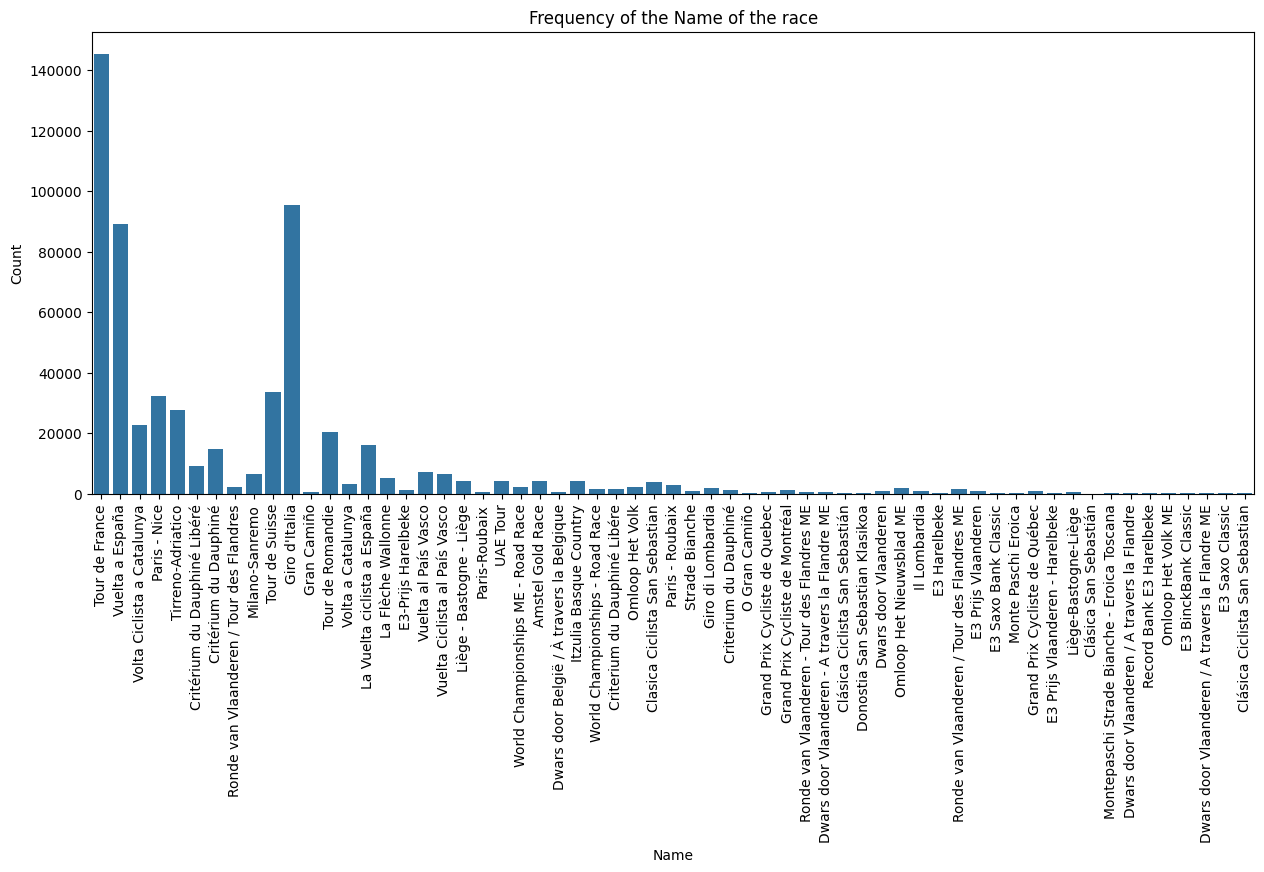

In [83]:
# displaying the name of the race
plt.figure(figsize=(15, 6))

sns.countplot(x='name', data=dataset_races)

plt.title('Frequency of the Name of the race')
plt.xlabel('Name')
plt.ylabel('Count')
plt.xticks(rotation=90)

plt.show()

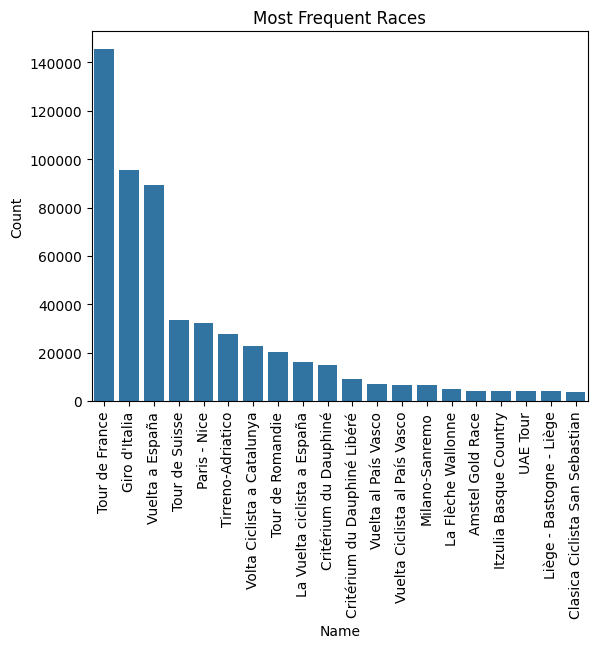

In [84]:
# most frequent races
top_20_index = dataset_races['name'].value_counts().nlargest(20).index
top_20_dataset = dataset_races[dataset_races['name'].isin(top_20_index)]

sns.countplot(x='name', data=top_20_dataset, order=top_20_index)

plt.title('Most Frequent Races')
plt.xlabel('Name')
plt.ylabel('Count')
plt.xticks(rotation=90)

plt.show()


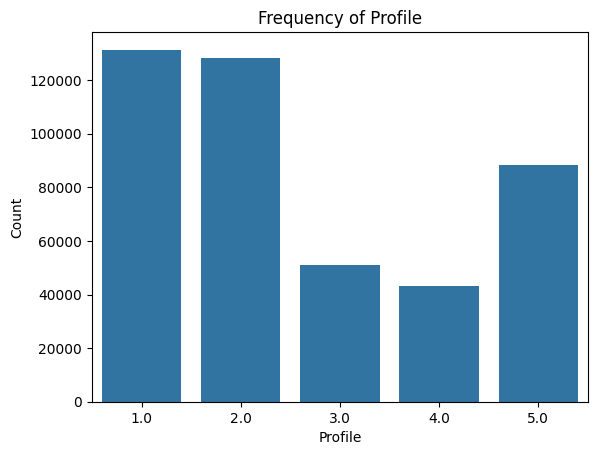

In [85]:
# displaying the profile type of the races

sns.countplot(x='profile', data=dataset_races)

plt.title('Frequency of Profile')
plt.xlabel('Profile')
plt.ylabel('Count')

plt.show()

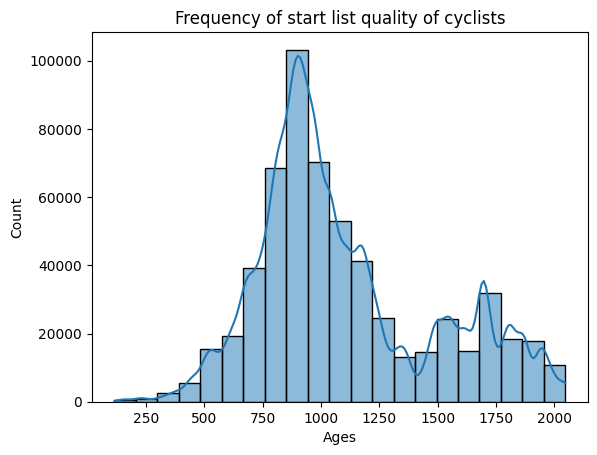

In [86]:
# displaying the startlist_quality of cyclists

bins = calculate_bins(dataset_races, method='sturges')
sns.histplot(x='startlist_quality',kde=True, data=dataset_races, bins=bins)

plt.title('Frequency of start list quality of cyclists')
plt.xlabel('Ages')
plt.ylabel('Count')

plt.show()

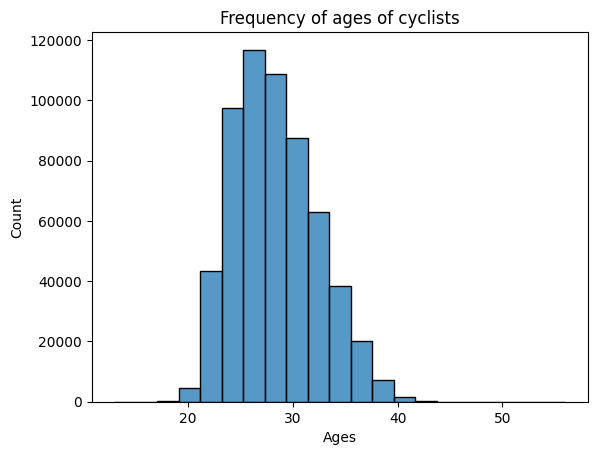

In [87]:
# displaying the ages of cyclists

bins = calculate_bins(dataset_races, method='sturges')
sns.histplot(x='cyclist_age', data=dataset_races, bins=bins)

plt.title('Frequency of ages of cyclists')
plt.xlabel('Ages')
plt.ylabel('Count')

plt.show()

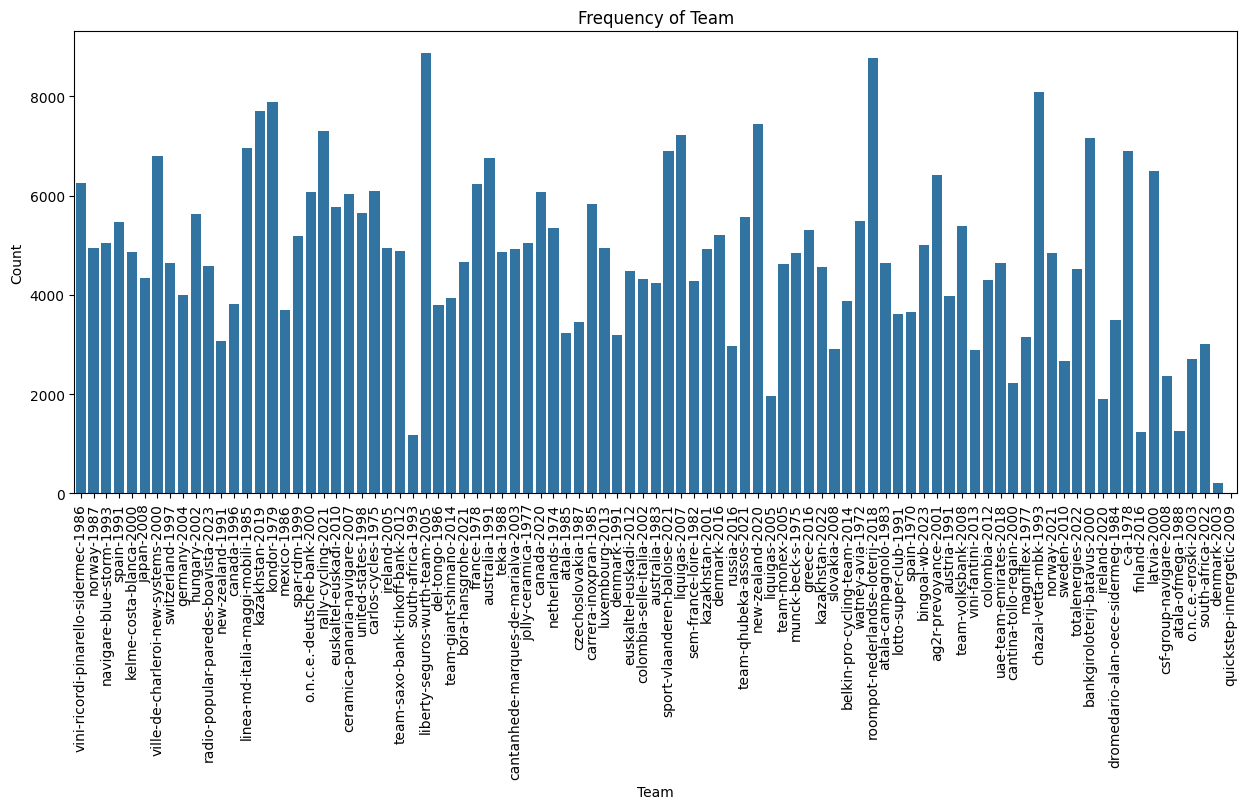

In [88]:
# displaying team of cyclists
plt.figure(figsize=(15, 6))

sns.countplot(x='cyclist_team', data=dataset_races)

plt.title('Frequency of Team')
plt.xlabel('Team')
plt.ylabel('Count')
plt.xticks(rotation=90)

plt.show()

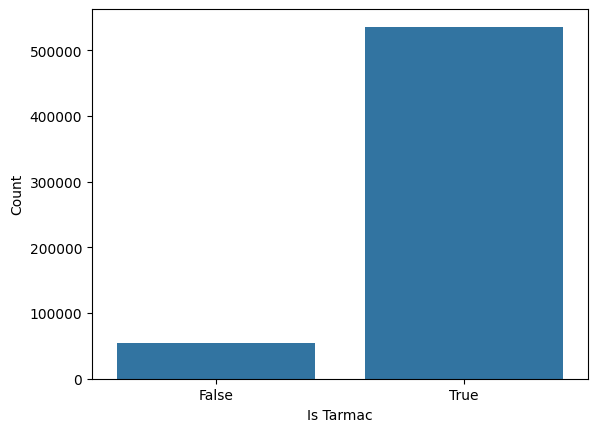

In [89]:
# displaying the type of the races

sns.countplot(x='is_tarmac', data=dataset_races)

plt.xlabel('Is Tarmac')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

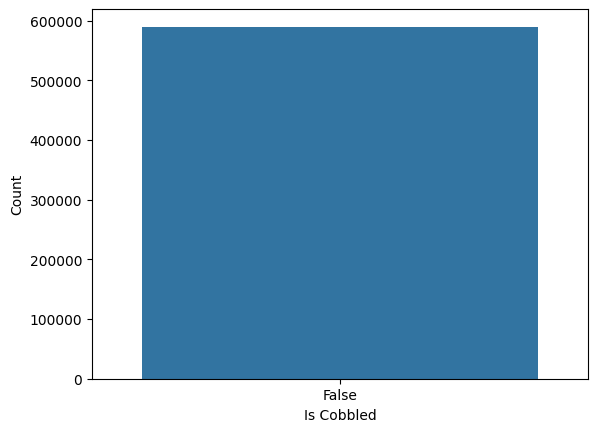

In [90]:
# displaying the type of the races

sns.countplot(x='is_cobbled', data=dataset_races)

plt.xlabel('Is Cobbled')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

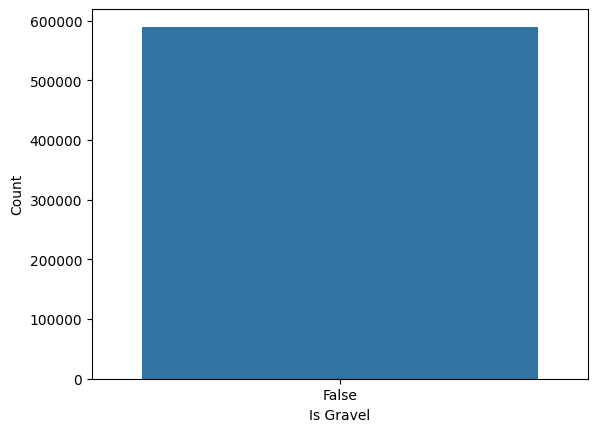

In [91]:
# displaying the type of the races

sns.countplot(x='is_gravel', data=dataset_races)


plt.xlabel('Is Gravel')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

As could be seen since we had analyzed the unique values of the dataset, *is_cobbled* and *is_gravel* only take the value False unlike *is_tarmac* which also takes on the value true although in the minority.

### Correlation

In [92]:
dataset_races_numerical = dataset_races.select_dtypes(include=[float, int])

In [93]:
dataset_races_numerical.columns

Index(['points', 'uci_points', 'length', 'climb_total', 'profile',
       'startlist_quality', 'average_temperature', 'position', 'cyclist_age',
       'delta'],
      dtype='object')

<Axes: >

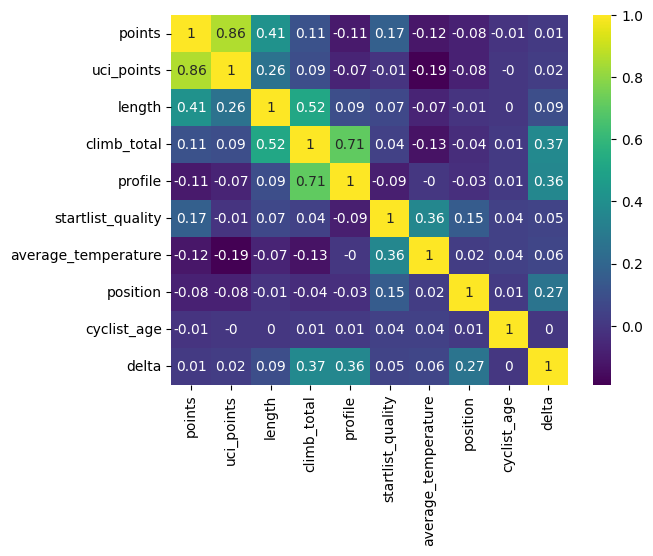

In [94]:
# Correlation matrix
correlation_races = dataset_races_numerical.corr('pearson')
sns.heatmap(correlation_races.round(2),annot=True, cmap='viridis')

From a first glance we can immediately see that:
- *points* and *uci_point* are strongly correlated; in fact uci_point represents an alternative form of points so it was to be expected. 
- *profile* is strongly correlated with *climb_total* and this indicates to us that rightly the more difficult a race is the more cyclists have to climb.

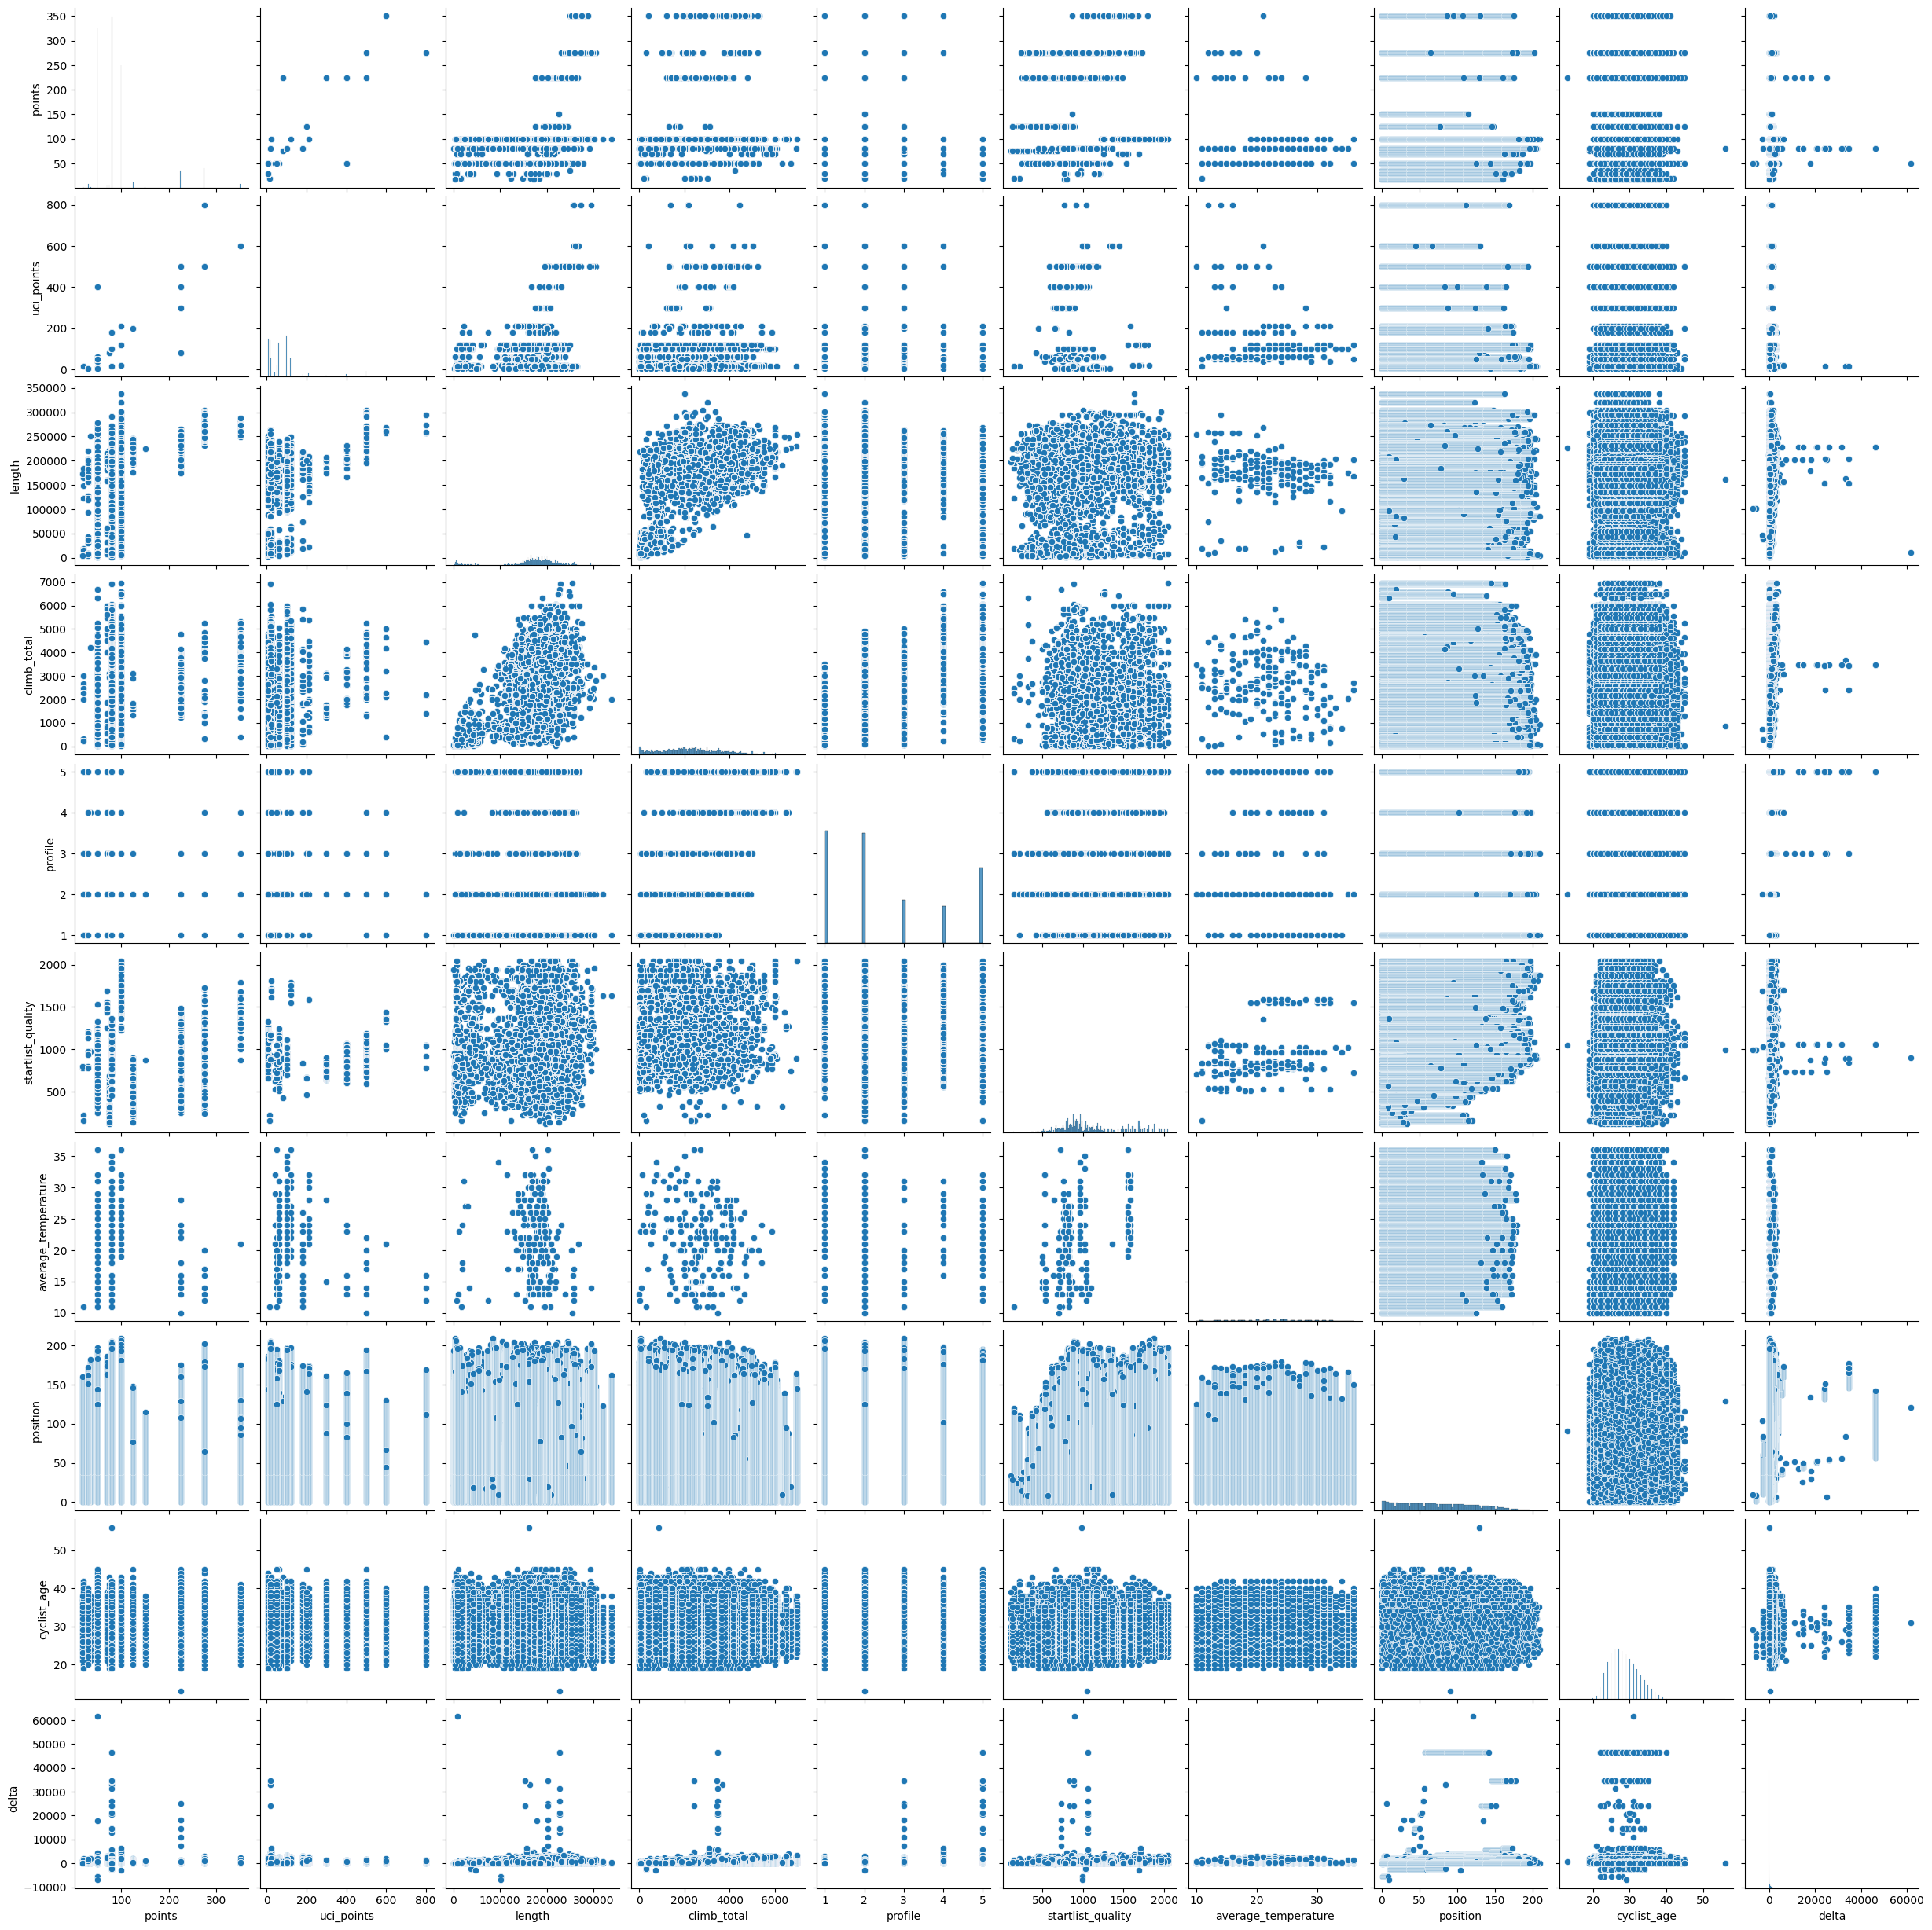

In [95]:
# generic pairplot
sns.pairplot(dataset_races_numerical)

<Axes: xlabel='points', ylabel='uci_points'>

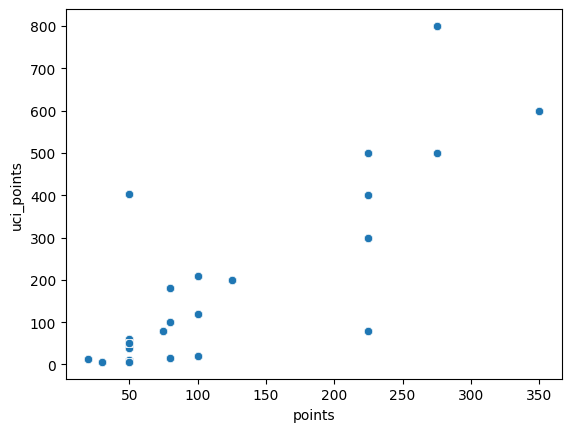

In [96]:
sns.scatterplot(dataset_races, x=dataset_races['points'], y=dataset_races['uci_points'])

From this plot, we can observe that the values of points and UCI points are correlated, although there are clearly several outliers, such as the pairing of a points value of 50 with a UCI points value of 400. Additionally, there is the case of a points value of 250, which is associated with multiple UCI points values.

<Axes: xlabel='profile', ylabel='climb_total'>

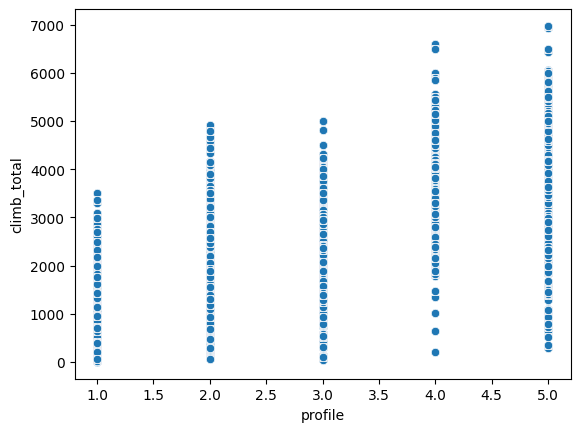

In [97]:
sns.scatterplot(dataset_races, x=dataset_races['profile'], y=dataset_races['climb_total'])

<Axes: xlabel='length', ylabel='climb_total'>

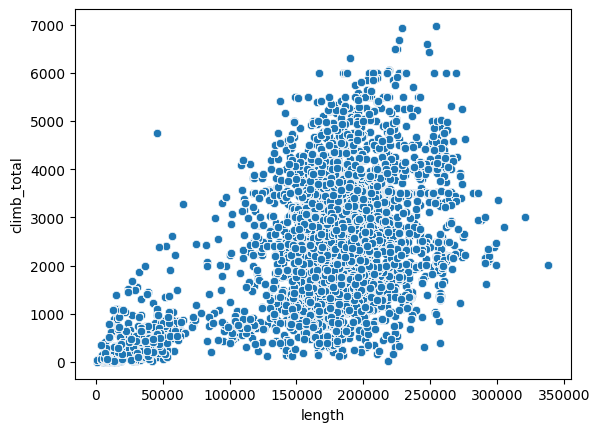

In [98]:
sns.scatterplot(dataset_races, x=dataset_races['length'], y=dataset_races['climb_total'])

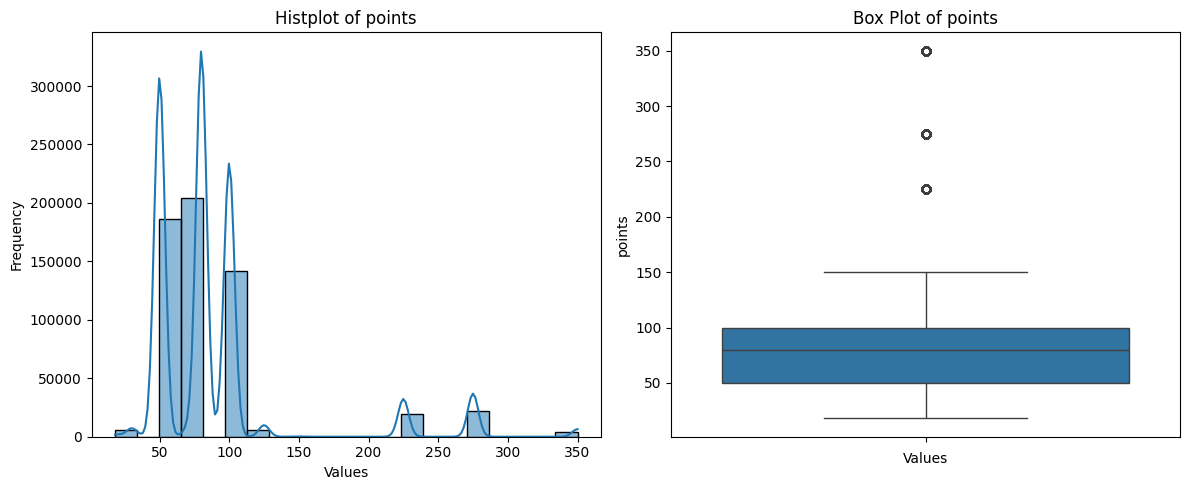

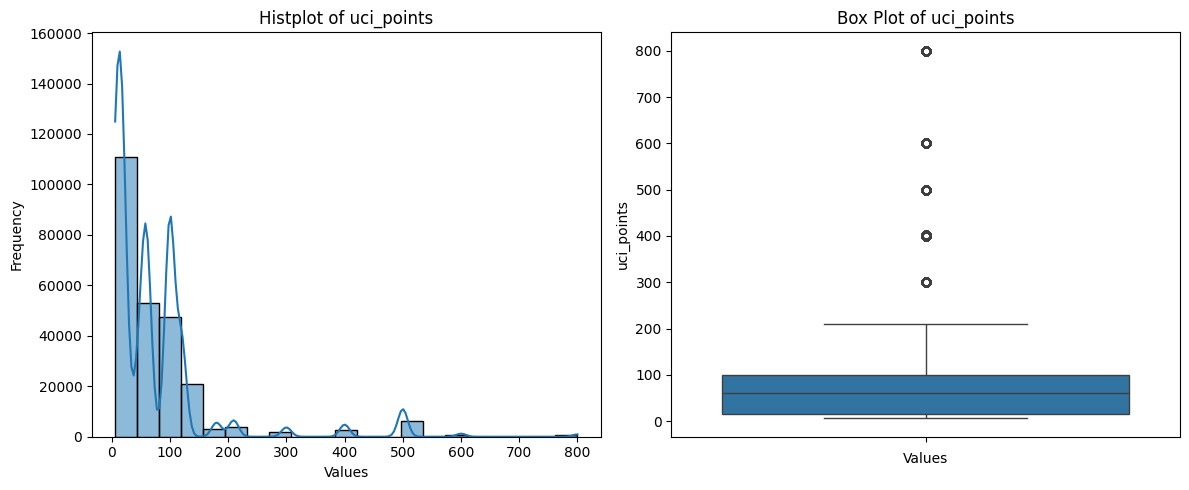

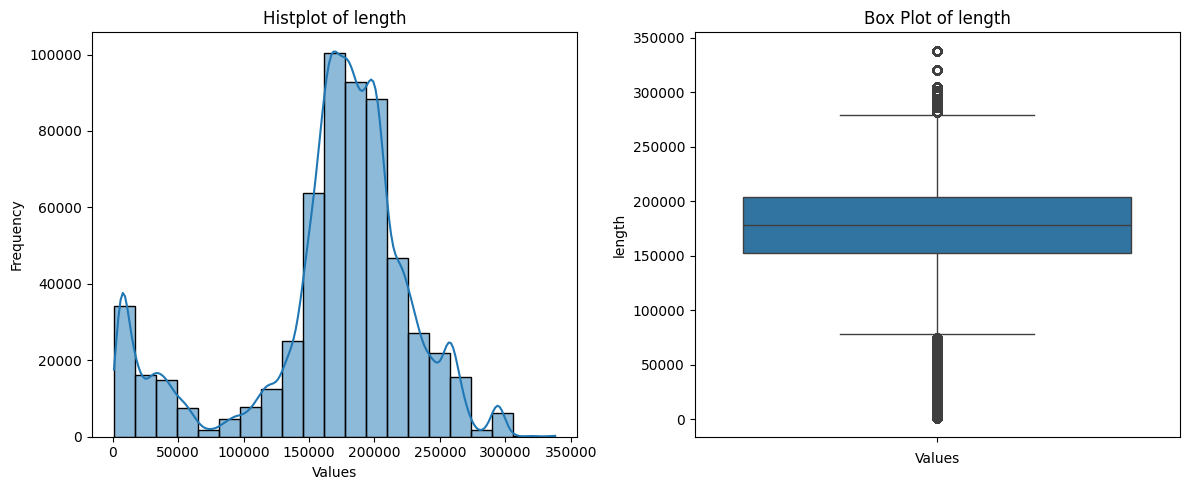

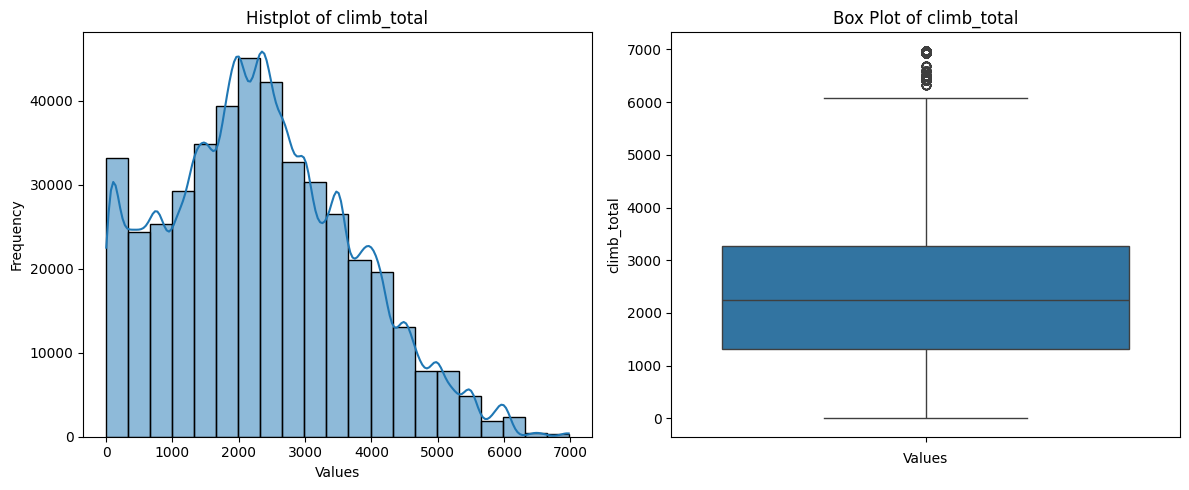

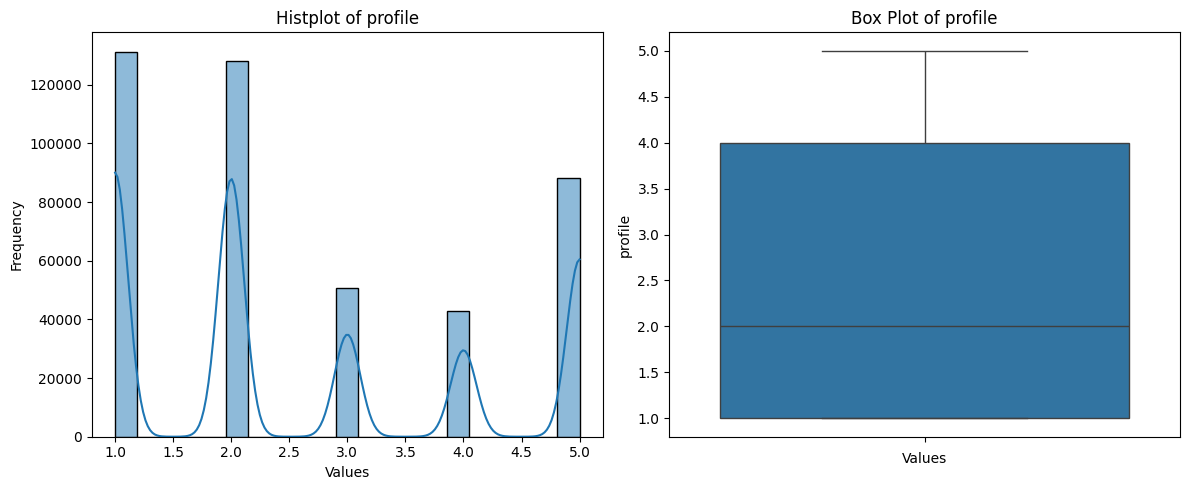

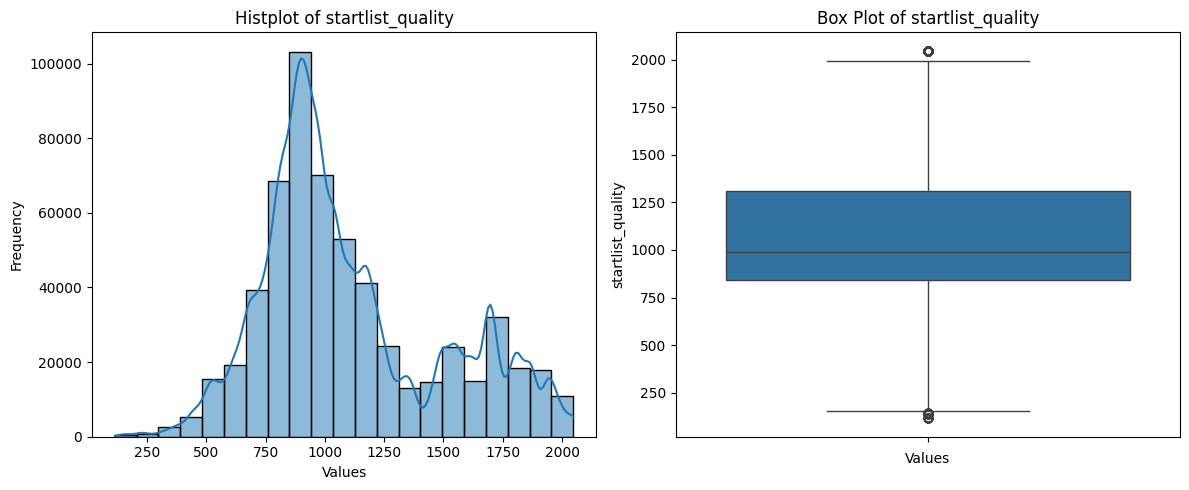

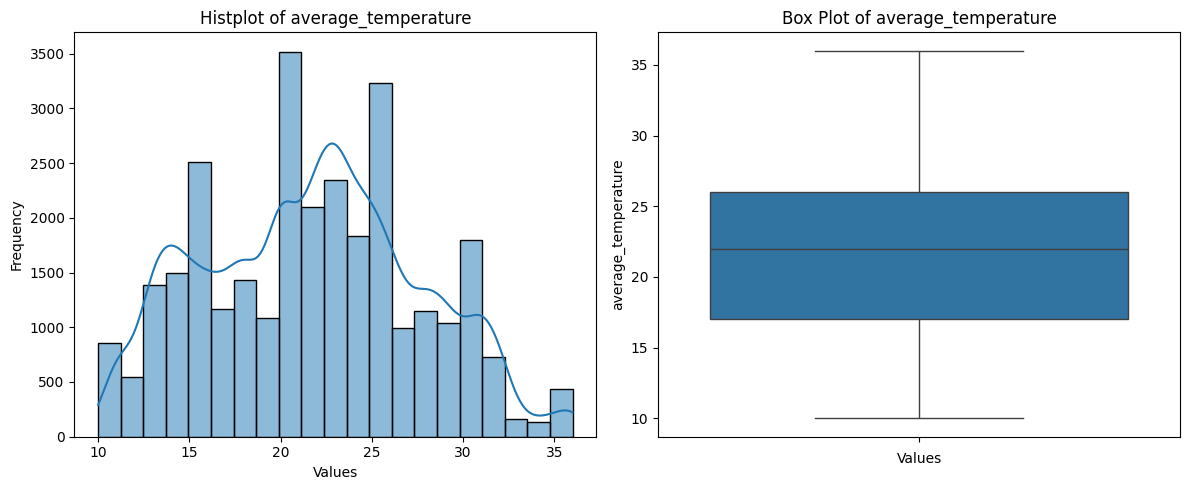

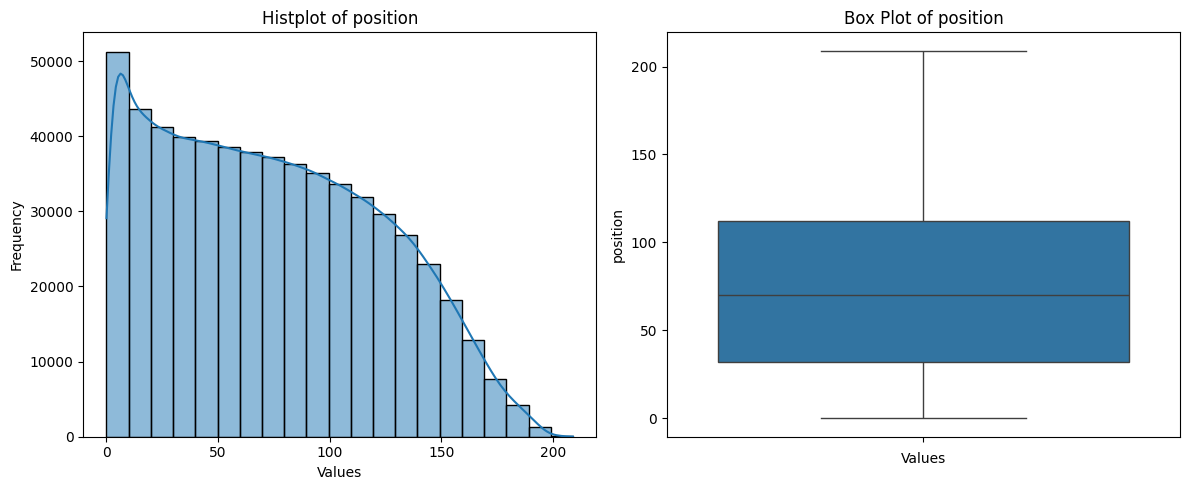

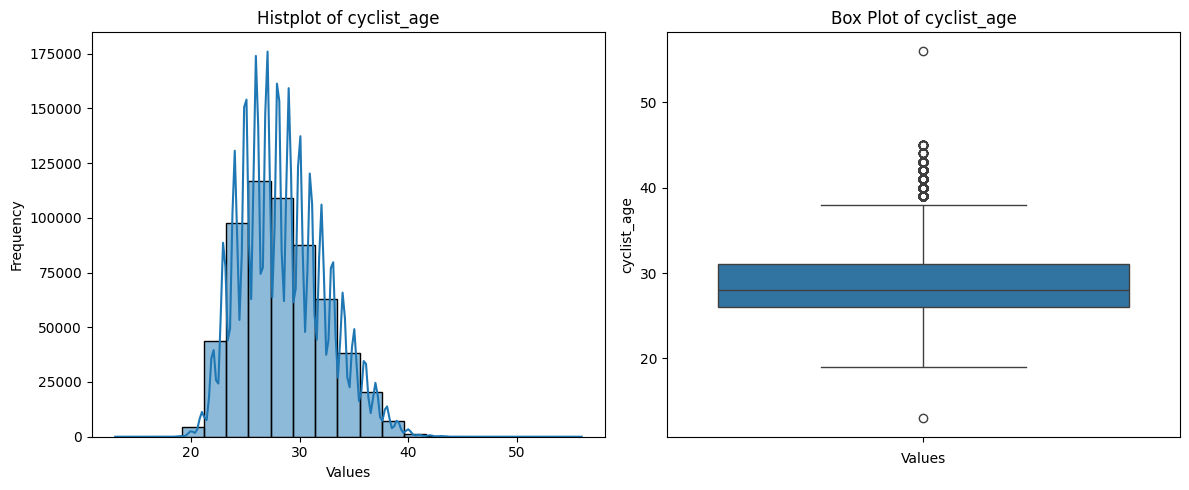

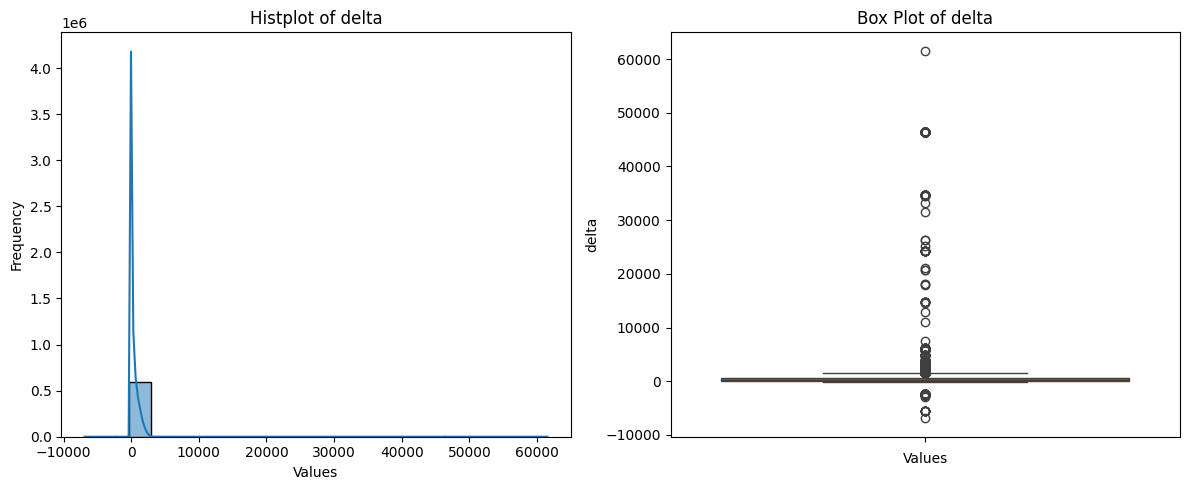

In [99]:
# displaying the distribution of numerical features with their associated boxplots in order to have a general overview

columns_to_select  = dataset_races.select_dtypes(include=['number']).columns

for col in columns_to_select:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 
    bins = calculate_bins(dataset_races, method='sturges')
    
    # histplot
    sns.histplot(dataset_races[col], bins=bins, kde=True, ax=axes[0], edgecolor='black')
    axes[0].set_title(f'Histplot of {col}')
    axes[0].set_xlabel('Values')
    axes[0].set_ylabel('Frequency')
    
    # box plot
    sns.boxplot(y=dataset_races[col], ax=axes[1])
    axes[1].set_title(f'Box Plot of {col}')
    axes[1].set_xlabel('Values')
    
    # showing graphs
    plt.tight_layout()
    plt.show()

### Normalizing the data: for this purpose, we are going to use the Standard Scaling 
**Standard scaling**

Data are standardized; removal of mean and rescaling to have standard deviation equal to 1.
$$
x = \dfrac{x - \mu}{\sigma}.
$$

In [100]:
normalized_dataset_r, normalization_scalers_dataset_r = center_and_scale(dataset_races_numerical)

In [101]:
# to check the result of normalization
normalized_dataset_r.describe()

,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,position,cyclist_age,delta
count,5.893880e+05,2.510860e+05,5.898650e+05,4.428200e+05,4.416710e+05,5.898650e+05,2.993300e+04,5.898650e+05,5.897520e+05,5.898650e+05
mean,3.411434e-17,4.406120e-17,-6.991413e-17,-1.379944e-17,-1.098783e-17,-2.224688e-16,-1.519217e-17,5.998835e-17,4.589280e-16,2.792831e-17
std,1.000001e+00,1.000002e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000017e+00,1.000001e+00,1.000001e+00,1.000001e+00
min,-1.308373e+00,-6.795747e-01,-2.568360e+00,-1.692559e+00,-1.080358e+00,-2.591161e+00,-1.993618e+00,-1.533334e+00,-4.016520e+00,-8.688769e+00
25%,-7.205186e-01,-5.805136e-01,-2.211799e-01,-7.425037e-01,-1.080358e+00,-6.756969e-01,-8.040848e-01,-8.722318e-01,-6.448257e-01,-4.843556e-01
50%,-1.694055e-01,-1.446446e-01,1.769885e-01,-5.485841e-02,-4.099989e-01,-2.973336e-01,4.558161e-02,-8.717239e-02,-1.261034e-01,-3.111565e-01
75%,1.980033e-01,2.516000e-01,5.689597e-01,6.851236e-01,9.307183e-01,5.461013e-01,7.253147e-01,7.805248e-01,6.519800e-01,2.440294e-01
max,4.790613e+00,7.185880e+00,2.652759e+00,3.375372e+00,1.601077e+00,2.485213e+00,2.424648e+00,2.784492e+00,7.136008e+00,7.251666e+01


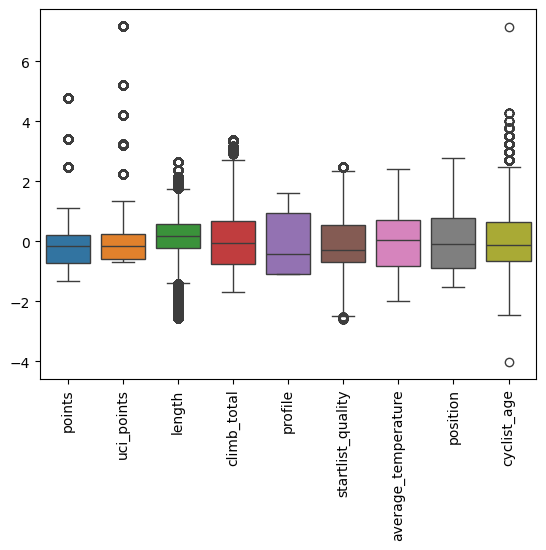

In [102]:
# normalized dataset

columns_to_plot = ['points', 'uci_points', 'length', 'climb_total', 'profile',
       'startlist_quality', 'average_temperature', 'position', 'cyclist_age']

sns.boxplot(data=normalized_dataset_r[columns_to_plot], orient="v")
plt.xticks(rotation=90)
plt.show()

We can observe that almost all the features, except for profile, average_temperature and position, have outliers.

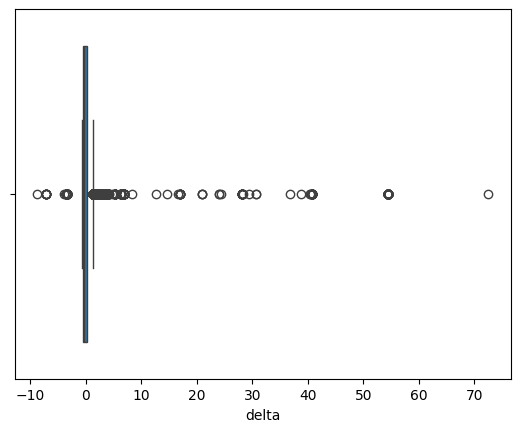

In [103]:
# normalized dataset
sns.boxplot(data=normalized_dataset_r["delta"], orient="h")
plt.show()

Delta feature also present many outliers

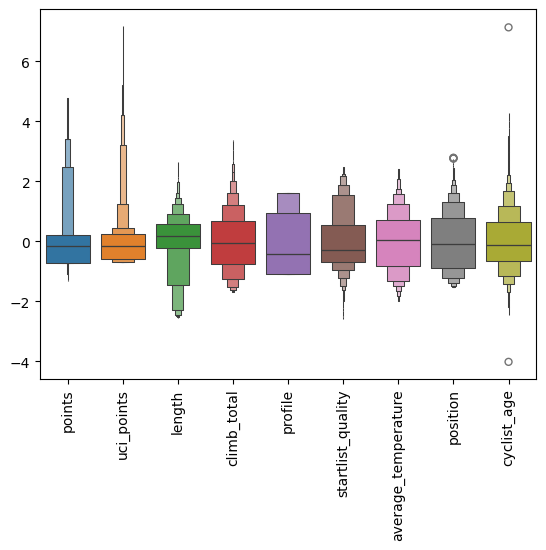

In [104]:
# normalized dataset

columns_to_plot = ['points', 'uci_points', 'length', 'climb_total', 'profile',
       'startlist_quality', 'average_temperature', 'position', 'cyclist_age']

sns.boxenplot(data=normalized_dataset_r[columns_to_plot], orient="v")
plt.xticks(rotation=90)
plt.show()

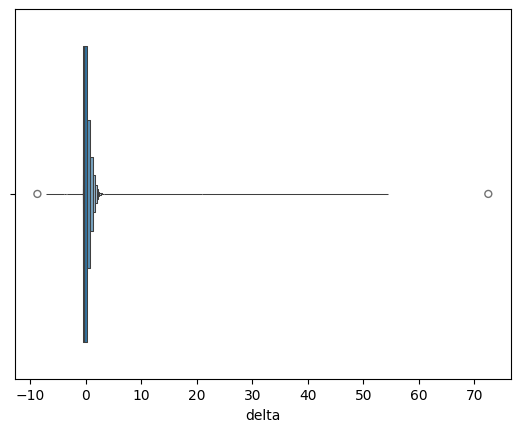

In [105]:
# normalized dataset
sns.boxenplot(data=normalized_dataset_r["delta"], orient="h")
plt.show()